In [1]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
from sklearn.model_selection import train_test_split

catmap = pd.read_csv("data/catmap.csv")
consDF = pd.read_parquet("data/Consumer.pqt").drop(columns=["credit_score"])
consDF = consDF.dropna(subset=['DQ_TARGET'])

acctDF = pd.read_parquet("data/Account.pqt")
trxnDF = pd.read_parquet("data/Transaction.pqt").drop_duplicates()

acctDF['balance_date'] = pd.to_datetime(acctDF['balance_date'])
trxnDF['posted_date'] = pd.to_datetime(trxnDF['posted_date'])

date_stats = acctDF.groupby('prism_consumer_id')['balance_date'].agg(['min', 'max'])
valid_ids = date_stats[(date_stats['max'] - date_stats['min']).dt.days <= 2].index

consDF = consDF[consDF['prism_consumer_id'].isin(valid_ids)]
acctDF = acctDF[acctDF['prism_consumer_id'].isin(valid_ids)]
trxnDF = trxnDF[trxnDF['prism_consumer_id'].isin(valid_ids)]

trxnDF = trxnDF.merge(catmap, left_on='category', right_on="category_id", how='left').drop(columns=["category_x"])
trxnDF['category'] = trxnDF['category_y'] 
trxnDF = trxnDF.merge(consDF[['prism_consumer_id', 'DQ_TARGET']], on='prism_consumer_id', how='inner')

user_targets_df = trxnDF.groupby('prism_consumer_id')['DQ_TARGET'].max().reset_index()

train_ids, test_ids = train_test_split(
    user_targets_df['prism_consumer_id'],
    test_size=0.2, 
    random_state=42,
    stratify=user_targets_df['DQ_TARGET']
)

test_ids_set = set(test_ids)

test_trxn = trxnDF[trxnDF['prism_consumer_id'].isin(test_ids_set)].copy()
train_trxn = trxnDF[~trxnDF['prism_consumer_id'].isin(test_ids_set)].copy()

test_acct = acctDF[acctDF['prism_consumer_id'].isin(test_ids_set)].copy()
train_acct = acctDF[~acctDF['prism_consumer_id'].isin(test_ids_set)].copy()

def calculate_running_balance(t_df, a_df):
    t_df = t_df.copy()
    
    t_df['signed_amount'] = np.where(
        t_df['credit_or_debit'] == 'DEBIT', 
        -t_df['amount'], 
        t_df['amount']
    )
    
    sort_cols = ['prism_consumer_id', 'posted_date']
    if 'prism_transaction_id' in t_df.columns:
        sort_cols.append('prism_transaction_id')
    t_df = t_df.sort_values(sort_cols)
    
    t_df['raw_cumsum'] = t_df.groupby('prism_consumer_id')['signed_amount'].cumsum()

    snapshot = a_df.sort_values('balance_date').groupby('prism_consumer_id').tail(1)
    snapshot = snapshot.rename(columns={'balance': 'snapshot_balance', 'balance_date': 'snapshot_date'})

    df_merged = t_df.merge(snapshot[['prism_consumer_id', 'snapshot_date', 'snapshot_balance']], on='prism_consumer_id', how='left')

    anchor = df_merged[df_merged['posted_date'] <= df_merged['snapshot_date']].groupby('prism_consumer_id')['raw_cumsum'].last().rename('cumsum_at_snapshot')
    df_merged = df_merged.merge(anchor, on='prism_consumer_id', how='left')

    df_merged['running_balance'] = (df_merged['raw_cumsum'] - df_merged['cumsum_at_snapshot']) + df_merged['snapshot_balance']
    
    out_cols = [
        'prism_consumer_id', 'posted_date', 'category_id', 'category', 
        'amount', 'signed_amount', 'credit_or_debit', 'running_balance', 'DQ_TARGET'
    ]
    out_cols = [c for c in out_cols if c in df_merged.columns]
    
    return df_merged[out_cols]

history_train = calculate_running_balance(train_trxn, train_acct)
history_test = calculate_running_balance(test_trxn, test_acct)

print(f"--- Test Set Stats ---")
print(f"Total Consumers: {history_test['prism_consumer_id'].nunique()}")
print(f"Target Ratio:    {history_test.groupby('prism_consumer_id')['DQ_TARGET'].max().mean():.1%}")

print(f"\n--- Train Set Stats ---")
print(f"Total Consumers: {history_train['prism_consumer_id'].nunique()}")
print(f"Target Ratio:    {history_train.groupby('prism_consumer_id')['DQ_TARGET'].max().mean():.2%}")

print("\nSample Train Row:")
print(history_train.head(1))

--- Test Set Stats ---
Total Consumers: 1976
Target Ratio:    8.7%

--- Train Set Stats ---
Total Consumers: 7904
Target Ratio:    8.68%

Sample Train Row:
  prism_consumer_id posted_date  category_id            category  amount  \
0                 0  2021-03-16           14  FOOD_AND_BEVERAGES   27.62   

   signed_amount credit_or_debit  running_balance  DQ_TARGET  
0         -27.62           DEBIT          1321.92        0.0  



--- PROCESSING TRAINING SET ---
Extracting FFT & Weekly Habit Features...
Extracting Account & Liquidity Features...
Extracting Income Features...
Extracting Balance Dynamics...
Extracting Balance Magnitudes...

--- PROCESSING TEST SET ---
Extracting FFT & Weekly Habit Features...
Extracting Account & Liquidity Features...
Extracting Income Features...
Extracting Balance Dynamics...
Extracting Balance Magnitudes...

--- TRAINING NATIVE XGBOOST ---
[0]	validation_0-logloss:0.68165	validation_1-logloss:0.68143
[100]	validation_0-logloss:0.44632	validation_1-logloss:0.47254
[200]	validation_0-logloss:0.36880	validation_1-logloss:0.41885
[300]	validation_0-logloss:0.31707	validation_1-logloss:0.38727
[400]	validation_0-logloss:0.27280	validation_1-logloss:0.36222
[500]	validation_0-logloss:0.23808	validation_1-logloss:0.34355
[600]	validation_0-logloss:0.20888	validation_1-logloss:0.32913
[700]	validation_0-logloss:0.18345	validation_1-logloss:0.31775
[800]	validation_0-logloss:0.16109	va

/var/folders/6r/152n25q91lzcqtjmm1gt04vc0000gn/T/ipykernel_71821/2967718631.py:319: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(20), x='Importance', y='Feature', palette='viridis')


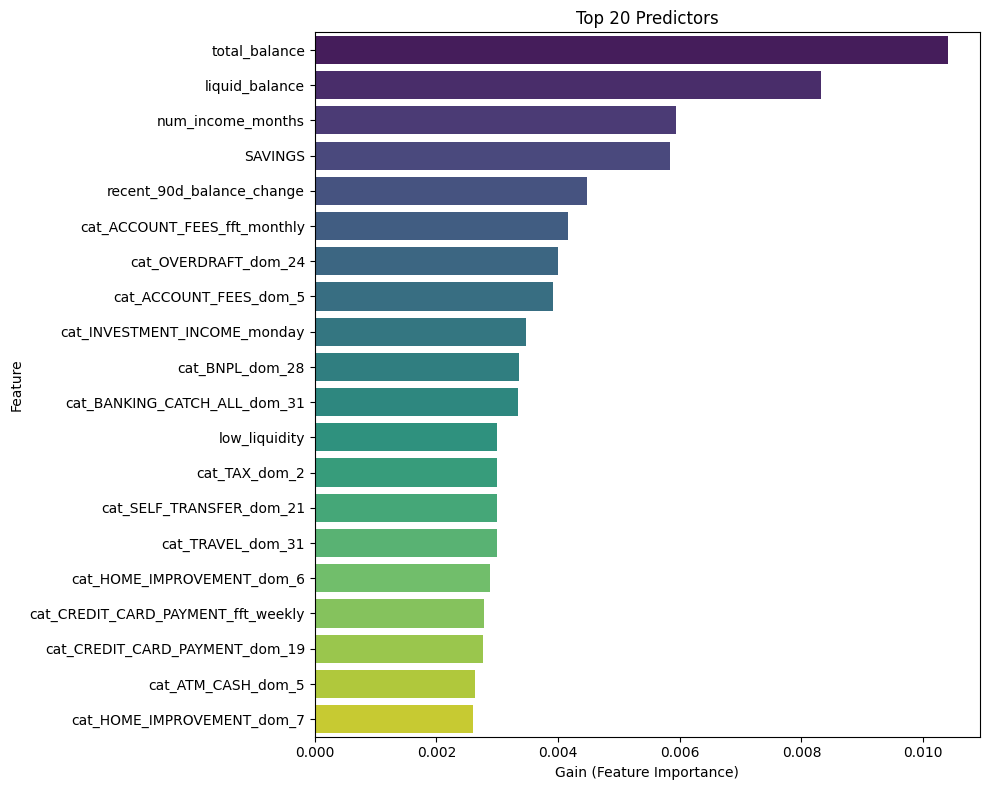

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve
from sklearn.preprocessing import StandardScaler


def extract_consumer_habits(df):
    df = df.copy()
    df['posted_date'] = pd.to_datetime(df['posted_date'])
    
    # 1. Setup Temporal Columns
    df['day_name'] = df['posted_date'].dt.day_name().str.lower()
    df['day_of_month'] = df['posted_date'].dt.day
    
    # --- PART A1: Weekly Time-Domain (Original) ---
    day_avg = df.groupby(['prism_consumer_id', 'category', 'day_name'])['signed_amount'].mean().reset_index()
    weekly_pivot = day_avg.pivot_table(
        index='prism_consumer_id', 
        columns=['category', 'day_name'], 
        values='signed_amount'
    ).fillna(0)
    weekly_pivot.columns = [f"cat_{c}_{d}" for c, d in weekly_pivot.columns]

    # --- PART A2: Monthly Time-Domain (New) ---
    dom_avg = df.groupby(['prism_consumer_id', 'category', 'day_of_month'])['signed_amount'].mean().reset_index()
    monthly_pivot = dom_avg.pivot_table(
        index='prism_consumer_id', 
        columns=['category', 'day_of_month'], 
        values='signed_amount'
    ).fillna(0)
    monthly_pivot.columns = [f"cat_{c}_dom_{d}" for c, d in monthly_pivot.columns]

    # --- PART B: Dual-Frequency FFT (Weekly + Monthly) ---
    def get_dual_fft_power(series):
        if len(series) < 14 or series.sum() == 0:
            return 0, 0
            
        vals = series.values - series.mean()
        fft_mag = np.abs(np.fft.rfft(vals))
        fft_freq = np.fft.rfftfreq(len(vals), d=1)
        
        weekly_idx = np.argmin(np.abs(fft_freq - (1/7)))
        weekly_power = fft_mag[weekly_idx]
        
        if len(series) >= 28:
            monthly_idx = np.argmin(np.abs(fft_freq - (1/30)))
            monthly_power = fft_mag[monthly_idx]
        else:
            monthly_power = 0
            
        return weekly_power, monthly_power

    fft_results = []
    
    for (cons_id, cat), group in df.groupby(['prism_consumer_id', 'category']):
        daily_series = group.groupby('posted_date')['signed_amount'].sum()
        
        full_range = pd.date_range(daily_series.index.min(), daily_series.index.max())
        series = daily_series.reindex(full_range, fill_value=0)
        
        w_power, m_power = get_dual_fft_power(series)
        
        fft_results.append({
            'prism_consumer_id': cons_id,
            'category': cat,
            'fft_weekly_habit': w_power,
            'fft_monthly_habit': m_power
        })

    fft_df = pd.DataFrame(fft_results)
    
    fft_pivot_w = fft_df.pivot(index='prism_consumer_id', columns='category', values='fft_weekly_habit').fillna(0)
    fft_pivot_w.columns = [f"cat_{c}_fft_weekly" for c in fft_pivot_w.columns]
    
    fft_pivot_m = fft_df.pivot(index='prism_consumer_id', columns='category', values='fft_monthly_habit').fillna(0)
    fft_pivot_m.columns = [f"cat_{c}_fft_monthly" for c in fft_pivot_m.columns]

    # --- PART C: Merge All Features and Target ---
    target_map = df.groupby('prism_consumer_id')['DQ_TARGET'].first()
    
    history_test_df = weekly_pivot.join(monthly_pivot)\
                           .join(fft_pivot_w)\
                           .join(fft_pivot_m)\
                           .join(target_map)
    
    return history_test_df

# ==========================================
# 1. COMPONENT FEATURE EXTRACTORS
# ==========================================

def build_account_features(acctDF):
    agg_bal = acctDF.groupby("prism_consumer_id", as_index=False).agg(
        total_balance=("balance", "sum"),
        avg_balance=("balance", "mean"),
        max_balance=("balance", "max"),
        min_balance=("balance", "min"),
        std_balance=("balance", "std"),
        num_accounts=("balance", "count"),
    )

    pivot_bal = acctDF.pivot_table(
        index="prism_consumer_id", columns="account_type", values="balance", aggfunc="sum", fill_value=0
    ).reset_index()

    pivot_bal["checking_to_savings_ratio"] = pivot_bal.get("CHECKING", 0) / (pivot_bal.get("SAVINGS", 0) + 1)
    pivot_bal["has_savings_account"] = (pivot_bal.get("SAVINGS", 0) > 0).astype(int)
    
    keep_cols = ["prism_consumer_id", "checking_to_savings_ratio", "has_savings_account"]
    if "CHECKING" in pivot_bal: keep_cols.append("CHECKING")
    if "SAVINGS" in pivot_bal: keep_cols.append("SAVINGS")
    pivot_bal = pivot_bal[keep_cols]

    acctDF_copy = acctDF.copy()
    acctDF_copy["liquid_component"] = np.where(acctDF_copy["account_type"].isin(["CHECKING", "SAVINGS"]), acctDF_copy["balance"], 0)
    acctDF_copy["liquid_balance"] = acctDF_copy.groupby("prism_consumer_id")["liquid_component"].transform("sum")

    liquidity_flags = acctDF_copy.groupby("prism_consumer_id", as_index=False)["liquid_balance"].first()
    liquidity_flags["low_liquidity"] = (liquidity_flags["liquid_balance"] < 500).astype(int)
    liquidity_flags["is_liquid"] = (liquidity_flags["liquid_balance"] > 0).astype(int)

    return agg_bal, pivot_bal, liquidity_flags


def build_income_features(history_train):
    INCOME_CATEGORIES = ["DEPOSIT", "PAYCHECK", "PAYCHECK_PLACEHOLDER", "INVESTMENT_INCOME", "OTHER_BENEFITS", "UNEMPLOYMENT_BENEFITS", "PENSION"]
    income_txn = history_train[(history_train["credit_or_debit"] == "CREDIT") & (history_train["category"].isin(INCOME_CATEGORIES))].copy()
    income_txn["month"] = income_txn["posted_date"].dt.to_period("M")

    total_income = income_txn.groupby("prism_consumer_id", as_index=False)["amount"].sum().rename(columns={"amount": "total_income"})
    avg_monthly_income = income_txn.groupby(["prism_consumer_id", "month"])["amount"].sum().groupby("prism_consumer_id").mean().reset_index(name="avg_monthly_income")
    income_consistency = income_txn.groupby("prism_consumer_id")["month"].nunique().reset_index(name="num_income_months")
    income_sources = income_txn.groupby("prism_consumer_id")["category"].nunique().reset_index(name="num_income_sources")

    BENEFITS_CATS = ["OTHER_BENEFITS", "UNEMPLOYMENT_BENEFITS", "PENSION"]
    benefits_flag = income_txn[income_txn["category"].isin(BENEFITS_CATS)].groupby("prism_consumer_id").size().reset_index(name="benefits_txn_count")
    benefits_flag["has_benefits_income"] = (benefits_flag["benefits_txn_count"] > 0).astype(int)

    return total_income, avg_monthly_income, income_consistency, income_sources, benefits_flag[["prism_consumer_id", "has_benefits_income"]]


def build_balance_dynamics(history_train):
    df = history_train.sort_values(["prism_consumer_id", "posted_date"]).copy()
    df["daily_balance_change"] = df.groupby("prism_consumer_id")["running_balance"].diff()

    daily_change_features = df.groupby("prism_consumer_id", as_index=False).agg(
        mean_daily_change=("daily_balance_change", "mean"),
        std_daily_change=("daily_balance_change", "std"),
        max_daily_drop=("daily_balance_change", "min"),
        max_daily_increase=("daily_balance_change", "max"),
    )

    latest_dates = df.groupby("prism_consumer_id")["posted_date"].max().reset_index(name="latest_date")
    df = df.merge(latest_dates, on="prism_consumer_id")
    df["date_30d"] = df["latest_date"] - pd.Timedelta(days=30)
    df["date_90d"] = df["latest_date"] - pd.Timedelta(days=90)
    df["date_365d"] = df["latest_date"] - pd.Timedelta(days=365)

    ending_balance = df.groupby("prism_consumer_id")["running_balance"].last()

    def last_bal(date_col):
        filtered = df[df["posted_date"] <= df[date_col]]
        return filtered.groupby("prism_consumer_id")["running_balance"].last()

    recent_balance_features = pd.DataFrame({
        "recent_30d_balance_change": ending_balance - last_bal("date_30d"),
        "recent_90d_balance_change": ending_balance - last_bal("date_90d"),
    }).fillna(0).reset_index()

    mean_balance_features = pd.concat([
        df[df["posted_date"] >= df["date_30d"]].groupby("prism_consumer_id")["running_balance"].mean().rename("mean_balance_30d"),
        df[df["posted_date"] >= df["date_90d"]].groupby("prism_consumer_id")["running_balance"].mean().rename("mean_balance_90d"),
        df[df["posted_date"] >= df["date_365d"]].groupby("prism_consumer_id")["running_balance"].mean().rename("mean_balance_365d"),
    ], axis=1).reset_index()

    return daily_change_features, recent_balance_features, mean_balance_features

# ==========================================
# NEW: MAGNITUDE PERCENTILE FEATURE FUNCTION
# ==========================================
def build_balance_magnitude(history_train):
    # Create a quick copy of relevant columns to avoid SettingWithCopyWarning
    df = history_train[['prism_consumer_id', 'running_balance']].copy()
    df['abs_running_balance'] = df['running_balance'].abs()
    
    # Calculate quantiles and unstack
    magnitude_feats = df.groupby('prism_consumer_id')['abs_running_balance'].quantile([0.3, 0.5, 0.8]).unstack()
    magnitude_feats.columns = ['balance_magnitude_30pct', 'balance_magnitude_50pct', 'balance_magnitude_80pct']
    
    return magnitude_feats.reset_index()


# ==========================================
# 2. MASTER FEATURE EXTRACTION PIPELINE
# ==========================================

def extract_ALL_features(history_train, acct_df):
    """Combines FFT Habit features with the new Account/Income/Dynamics features."""
    
    print("Extracting FFT & Weekly Habit Features...")
    base_features = extract_consumer_habits(history_train)
    
    print("Extracting Account & Liquidity Features...")
    agg_bal, pivot_bal, liquidity_flags = build_account_features(acct_df)
    
    print("Extracting Income Features...")
    income_feats = build_income_features(history_train)
    
    print("Extracting Balance Dynamics...")
    balance_feats = build_balance_dynamics(history_train)
    
    print("Extracting Balance Magnitudes...") # NEW
    magnitude_feats = build_balance_magnitude(history_train) # NEW
    
    # Merge All DataFrames on prism_consumer_id
    history_test_df = base_features.copy()
    
    # Add magnitude_feats to the tuple of dataframes to merge # NEW
    all_new_dfs = (agg_bal, pivot_bal, liquidity_flags, *income_feats, *balance_feats, magnitude_feats) 
    
    for df in all_new_dfs:
        if 'prism_consumer_id' in df.columns:
            df = df.set_index('prism_consumer_id')
        history_test_df = history_test_df.join(df, how='left')
        
    return history_test_df.fillna(0).reset_index()


# ==========================================
# 3. EXECUTE ON TRAIN & TEST SETS
# ==========================================

print("\n--- PROCESSING TRAINING SET ---")
train_features_df = extract_ALL_features(history_train, acctDF) # Make sure you pass your specific train splits here

print("\n--- PROCESSING TEST SET ---")
test_features_df = extract_ALL_features(history_test, acctDF) # Make sure you pass your specific test splits here


# ==========================================
# 4. COLUMN ALIGNMENT & X/Y SPLIT
# ==========================================

X_train = train_features_df.drop(columns=['DQ_TARGET', 'prism_consumer_id', 'posted_date'], errors='ignore')
y_train = train_features_df['DQ_TARGET']

X_holdout = test_features_df.drop(columns=['DQ_TARGET', 'prism_consumer_id', 'posted_date'], errors='ignore')
y_holdout = test_features_df['DQ_TARGET']

# Add missing columns to holdout
missing_cols = set(X_train.columns) - set(X_holdout.columns)
for c in missing_cols:
    X_holdout[c] = 0

# Enforce exact column order
X_holdout = X_holdout[X_train.columns]


# ==========================================
# 5. XGBOOST TRAINING & EVALUATION
# ==========================================
print("\n--- TRAINING NATIVE XGBOOST ---")

ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.5,
    scale_pos_weight=ratio,
    max_delta_step=2, 
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_holdout, y_holdout)],
    verbose=100
)

# Predict Probabilities
xgb_train_probs = xgb_model.predict_proba(X_train)[:, 1]
xgb_test_probs = xgb_model.predict_proba(X_holdout)[:, 1]

print(f"\nTrain ROC AUC: {roc_auc_score(y_train, xgb_train_probs):.4f}")
print(f"Test ROC AUC:  {roc_auc_score(y_holdout, xgb_test_probs):.4f}")

fpr, tpr, thresholds = roc_curve(y_train, xgb_train_probs)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

roc_preds = (xgb_test_probs >= best_threshold).astype(int)

print(f"\n--- OPTIMAL ROC THRESHOLD SET OUTCOMES (Threshold = {best_threshold:.4f}) ---")
print(classification_report(y_holdout, roc_preds))

target_threshold = 0.20 
custom_preds = (xgb_test_probs >= target_threshold).astype(int)

print(f"\n--- CUSTOM BUSINESS THRESHOLD OUTCOMES (Threshold = {target_threshold:.2f}) ---")
print(classification_report(y_holdout, custom_preds))

# Plot the new top 20 features
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(20), x='Importance', y='Feature', palette='viridis')
plt.title('Top 20 Predictors')
plt.xlabel('Gain (Feature Importance)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


--- PROCESSING TRAINING SET ---
Extracting FFT & Weekly Habit Features...
Extracting Account & Liquidity Features...
Extracting Income Features...
Extracting Balance Dynamics...

--- PROCESSING TEST SET ---
Extracting FFT & Weekly Habit Features...
Extracting Account & Liquidity Features...
Extracting Income Features...
Extracting Balance Dynamics...

--- TRAINING NATIVE XGBOOST ---
[0]	validation_0-logloss:0.68248	validation_1-logloss:0.68156
[100]	validation_0-logloss:0.45002	validation_1-logloss:0.47669
[200]	validation_0-logloss:0.37488	validation_1-logloss:0.42371
[300]	validation_0-logloss:0.32019	validation_1-logloss:0.38851
[400]	validation_0-logloss:0.27512	validation_1-logloss:0.36205
[500]	validation_0-logloss:0.24004	validation_1-logloss:0.34523
[600]	validation_0-logloss:0.21187	validation_1-logloss:0.33308
[700]	validation_0-logloss:0.18646	validation_1-logloss:0.32115
[800]	validation_0-logloss:0.16380	validation_1-logloss:0.31348
[900]	validation_0-logloss:0.14406	vali

/var/folders/6r/152n25q91lzcqtjmm1gt04vc0000gn/T/ipykernel_71821/1845960035.py:316: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(20), x='Importance', y='Feature', palette='viridis')


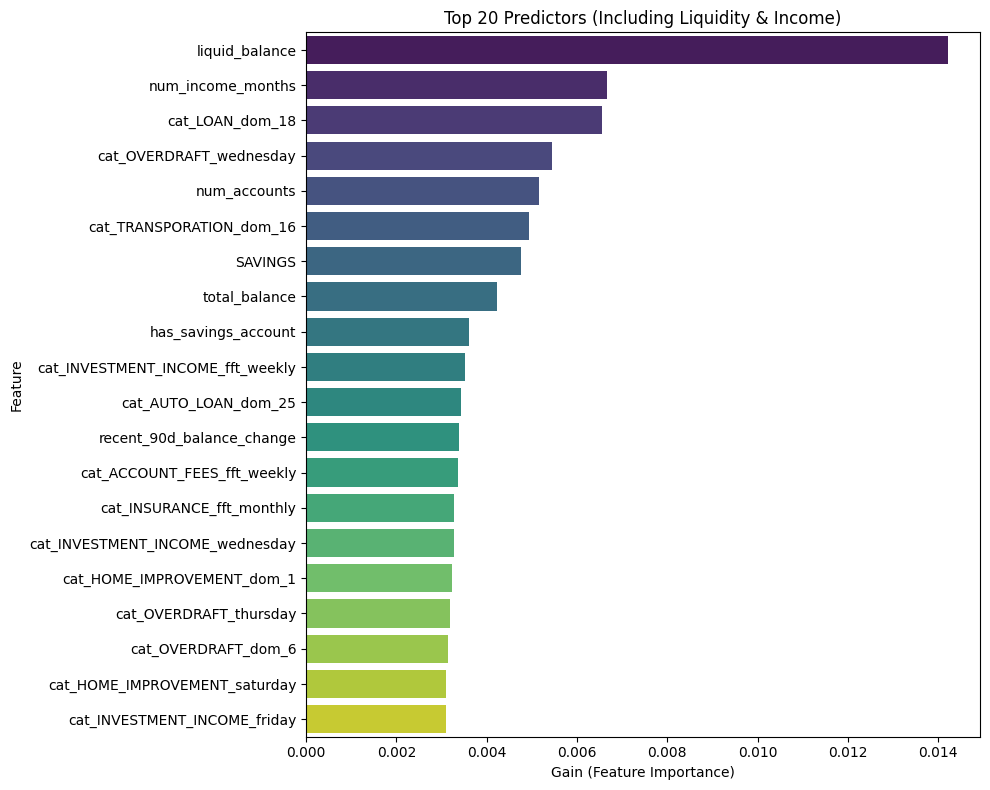

In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve
from sklearn.preprocessing import StandardScaler


def extract_consumer_habits(df):
    df = df.copy()
    df['posted_date'] = pd.to_datetime(df['posted_date'])
    
    # 1. Setup Temporal Columns
    df['day_name'] = df['posted_date'].dt.day_name().str.lower()
    df['day_of_month'] = df['posted_date'].dt.day
    
    # --- PART A1: Weekly Time-Domain (Original) ---
    day_avg = df.groupby(['prism_consumer_id', 'category', 'day_name'])['signed_amount'].mean().reset_index()
    weekly_pivot = day_avg.pivot_table(
        index='prism_consumer_id', 
        columns=['category', 'day_name'], 
        values='signed_amount'
    ).fillna(0)
    weekly_pivot.columns = [f"cat_{c}_{d}" for c, d in weekly_pivot.columns]

    # --- PART A2: Monthly Time-Domain (New) ---
    dom_avg = df.groupby(['prism_consumer_id', 'category', 'day_of_month'])['signed_amount'].mean().reset_index()
    monthly_pivot = dom_avg.pivot_table(
        index='prism_consumer_id', 
        columns=['category', 'day_of_month'], 
        values='signed_amount'
    ).fillna(0)
    # Naming convention: cat_GROCERIES_dom_1, cat_GROCERIES_dom_15, etc.
    monthly_pivot.columns = [f"cat_{c}_dom_{d}" for c, d in monthly_pivot.columns]

    # --- PART B: Dual-Frequency FFT (Weekly + Monthly) ---
    def get_dual_fft_power(series):
        # We need more history to detect a monthly cycle reliably
        if len(series) < 14 or series.sum() == 0:
            return 0, 0
            
        vals = series.values - series.mean()
        fft_mag = np.abs(np.fft.rfft(vals))
        fft_freq = np.fft.rfftfreq(len(vals), d=1)
        
        # 1. Find power at Weekly Frequency (1/7)
        weekly_idx = np.argmin(np.abs(fft_freq - (1/7)))
        weekly_power = fft_mag[weekly_idx]
        
        # 2. Find power at Monthly Frequency (1/30)
        # We only check this if the history is long enough (>28 days)
        if len(series) >= 28:
            monthly_idx = np.argmin(np.abs(fft_freq - (1/30)))
            monthly_power = fft_mag[monthly_idx]
        else:
            monthly_power = 0
            
        return weekly_power, monthly_power

    fft_results = []
    
    for (cons_id, cat), group in df.groupby(['prism_consumer_id', 'category']):
        # Sum signed_amounts by date to create a clean time series
        daily_series = group.groupby('posted_date')['signed_amount'].sum()
        
        # Reindex to full date range to capture 0-spend days
        full_range = pd.date_range(daily_series.index.min(), daily_series.index.max())
        series = daily_series.reindex(full_range, fill_value=0)
        
        w_power, m_power = get_dual_fft_power(series)
        
        fft_results.append({
            'prism_consumer_id': cons_id,
            'category': cat,
            'fft_weekly_habit': w_power,
            'fft_monthly_habit': m_power
        })

    fft_df = pd.DataFrame(fft_results)
    
    # Pivot for Weekly FFT Features
    fft_pivot_w = fft_df.pivot(index='prism_consumer_id', columns='category', values='fft_weekly_habit').fillna(0)
    fft_pivot_w.columns = [f"cat_{c}_fft_weekly" for c in fft_pivot_w.columns]
    
    # Pivot for Monthly FFT Features
    fft_pivot_m = fft_df.pivot(index='prism_consumer_id', columns='category', values='fft_monthly_habit').fillna(0)
    fft_pivot_m.columns = [f"cat_{c}_fft_monthly" for c in fft_pivot_m.columns]

    # --- PART C: Merge All Features and Target ---
    target_map = df.groupby('prism_consumer_id')['DQ_TARGET'].first()
    
    final_df = weekly_pivot.join(monthly_pivot)\
                           .join(fft_pivot_w)\
                           .join(fft_pivot_m)\
                           .join(target_map)
    
    return final_df
# ==========================================
# 1. NEW COMPONENT FEATURE EXTRACTORS
# ==========================================

def build_account_features(acctDF):
    agg_bal = acctDF.groupby("prism_consumer_id", as_index=False).agg(
        total_balance=("balance", "sum"),
        avg_balance=("balance", "mean"),
        max_balance=("balance", "max"),
        min_balance=("balance", "min"),
        std_balance=("balance", "std"),
        num_accounts=("balance", "count"),
    )

    pivot_bal = acctDF.pivot_table(
        index="prism_consumer_id", columns="account_type", values="balance", aggfunc="sum", fill_value=0
    ).reset_index()

    pivot_bal["checking_to_savings_ratio"] = pivot_bal.get("CHECKING", 0) / (pivot_bal.get("SAVINGS", 0) + 1)
    pivot_bal["has_savings_account"] = (pivot_bal.get("SAVINGS", 0) > 0).astype(int)
    
    # Safely select columns in case some account types are missing in a split
    keep_cols = ["prism_consumer_id", "checking_to_savings_ratio", "has_savings_account"]
    if "CHECKING" in pivot_bal: keep_cols.append("CHECKING")
    if "SAVINGS" in pivot_bal: keep_cols.append("SAVINGS")
    pivot_bal = pivot_bal[keep_cols]

    acctDF_copy = acctDF.copy()
    acctDF_copy["liquid_component"] = np.where(acctDF_copy["account_type"].isin(["CHECKING", "SAVINGS"]), acctDF_copy["balance"], 0)
    acctDF_copy["liquid_balance"] = acctDF_copy.groupby("prism_consumer_id")["liquid_component"].transform("sum")

    liquidity_flags = acctDF_copy.groupby("prism_consumer_id", as_index=False)["liquid_balance"].first()
    liquidity_flags["low_liquidity"] = (liquidity_flags["liquid_balance"] < 500).astype(int)
    liquidity_flags["is_liquid"] = (liquidity_flags["liquid_balance"] > 0).astype(int)

    return agg_bal, pivot_bal, liquidity_flags

def build_income_features(history_df):
    INCOME_CATEGORIES = ["DEPOSIT", "PAYCHECK", "PAYCHECK_PLACEHOLDER", "INVESTMENT_INCOME", "OTHER_BENEFITS", "UNEMPLOYMENT_BENEFITS", "PENSION"]
    income_txn = history_df[(history_df["credit_or_debit"] == "CREDIT") & (history_df["category"].isin(INCOME_CATEGORIES))].copy()
    income_txn["month"] = income_txn["posted_date"].dt.to_period("M")

    total_income = income_txn.groupby("prism_consumer_id", as_index=False)["amount"].sum().rename(columns={"amount": "total_income"})
    avg_monthly_income = income_txn.groupby(["prism_consumer_id", "month"])["amount"].sum().groupby("prism_consumer_id").mean().reset_index(name="avg_monthly_income")
    income_consistency = income_txn.groupby("prism_consumer_id")["month"].nunique().reset_index(name="num_income_months")
    income_sources = income_txn.groupby("prism_consumer_id")["category"].nunique().reset_index(name="num_income_sources")

    BENEFITS_CATS = ["OTHER_BENEFITS", "UNEMPLOYMENT_BENEFITS", "PENSION"]
    benefits_flag = income_txn[income_txn["category"].isin(BENEFITS_CATS)].groupby("prism_consumer_id").size().reset_index(name="benefits_txn_count")
    benefits_flag["has_benefits_income"] = (benefits_flag["benefits_txn_count"] > 0).astype(int)

    return total_income, avg_monthly_income, income_consistency, income_sources, benefits_flag[["prism_consumer_id", "has_benefits_income"]]

def build_balance_dynamics(history_df):
    df = history_df.sort_values(["prism_consumer_id", "posted_date"]).copy()
    df["daily_balance_change"] = df.groupby("prism_consumer_id")["running_balance"].diff()

    daily_change_features = df.groupby("prism_consumer_id", as_index=False).agg(
        mean_daily_change=("daily_balance_change", "mean"),
        std_daily_change=("daily_balance_change", "std"),
        max_daily_drop=("daily_balance_change", "min"),
        max_daily_increase=("daily_balance_change", "max"),
    )

    latest_dates = df.groupby("prism_consumer_id")["posted_date"].max().reset_index(name="latest_date")
    df = df.merge(latest_dates, on="prism_consumer_id")
    df["date_30d"] = df["latest_date"] - pd.Timedelta(days=30)
    df["date_90d"] = df["latest_date"] - pd.Timedelta(days=90)
    df["date_365d"] = df["latest_date"] - pd.Timedelta(days=365)

    ending_balance = df.groupby("prism_consumer_id")["running_balance"].last()

    def last_bal(date_col):
        filtered = df[df["posted_date"] <= df[date_col]]
        return filtered.groupby("prism_consumer_id")["running_balance"].last()

    recent_balance_features = pd.DataFrame({
        "recent_30d_balance_change": ending_balance - last_bal("date_30d"),
        "recent_90d_balance_change": ending_balance - last_bal("date_90d"),
    }).fillna(0).reset_index()

    mean_balance_features = pd.concat([
        df[df["posted_date"] >= df["date_30d"]].groupby("prism_consumer_id")["running_balance"].mean().rename("mean_balance_30d"),
        df[df["posted_date"] >= df["date_90d"]].groupby("prism_consumer_id")["running_balance"].mean().rename("mean_balance_90d"),
        df[df["posted_date"] >= df["date_365d"]].groupby("prism_consumer_id")["running_balance"].mean().rename("mean_balance_365d"),
    ], axis=1).reset_index()

    return daily_change_features, recent_balance_features, mean_balance_features


# ==========================================
# 2. MASTER FEATURE EXTRACTION PIPELINE
# ==========================================

def extract_ALL_features(history_df, acct_df):
    """Combines FFT Habit features with the new Account/Income/Dynamics features."""
    
    # 1. Base Habit Features (Your original FFT/Pivot function)
    print("Extracting FFT & Weekly Habit Features...")
    base_features = extract_consumer_habits(history_df)
    
    # 2. Extract New Features
    print("Extracting Account & Liquidity Features...")
    agg_bal, pivot_bal, liquidity_flags = build_account_features(acct_df)
    
    print("Extracting Income Features...")
    income_feats = build_income_features(history_df)
    
    print("Extracting Balance Dynamics...")
    balance_feats = build_balance_dynamics(history_df)
    
    # 3. Merge All DataFrames on prism_consumer_id
    final_df = base_features.copy()
    
    all_new_dfs = (agg_bal, pivot_bal, liquidity_flags, *income_feats, *balance_feats)
    
    for df in all_new_dfs:
        if 'prism_consumer_id' in df.columns:
            df = df.set_index('prism_consumer_id')
        final_df = final_df.join(df, how='left')
        
    return final_df.fillna(0).reset_index()


# ==========================================
# 3. EXECUTE ON TRAIN & TEST SETS
# ==========================================

print("\n--- PROCESSING TRAINING SET ---")
# Uses the train_acct split from your previous step to prevent data leakage
train_features_df = extract_ALL_features(history_train, train_acct)

print("\n--- PROCESSING TEST SET ---")
test_features_df = extract_ALL_features(history_test, test_acct)


# ==========================================
# 4. COLUMN ALIGNMENT & X/Y SPLIT
# ==========================================

X_train = train_features_df.drop(columns=['DQ_TARGET', 'prism_consumer_id', 'posted_date'], errors='ignore')
y_train = train_features_df['DQ_TARGET']

X_holdout = test_features_df.drop(columns=['DQ_TARGET', 'prism_consumer_id', 'posted_date'], errors='ignore')
y_holdout = test_features_df['DQ_TARGET']

# Add missing columns to holdout
missing_cols = set(X_train.columns) - set(X_holdout.columns)
for c in missing_cols:
    X_holdout[c] = 0

# Enforce exact column order
X_holdout = X_holdout[X_train.columns]


# ==========================================
# 5. XGBOOST TRAINING & EVALUATION
# ==========================================
print("\n--- TRAINING NATIVE XGBOOST ---")

# Calculate penalty ratio directly from the dataset
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.5,
    scale_pos_weight=ratio,
    max_delta_step=2, # Prevents probability crushing
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_holdout, y_holdout)],
    verbose=100
)
# Predict Probabilities
xgb_train_probs = xgb_model.predict_proba(X_train)[:, 1]
xgb_test_probs = xgb_model.predict_proba(X_holdout)[:, 1]

print(f"\nTrain ROC AUC: {roc_auc_score(y_train, xgb_train_probs):.4f}")
print(f"Test ROC AUC:  {roc_auc_score(y_holdout, xgb_test_probs):.4f}")

# FIX: Use xgb_train_probs instead of train_probs
fpr, tpr, thresholds = roc_curve(y_train, xgb_train_probs)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

# Predict using Youden's J Optimal Threshold
roc_preds = (xgb_test_probs >= best_threshold).astype(int)

print(f"\n--- OPTIMAL ROC THRESHOLD SET OUTCOMES (Threshold = {best_threshold:.4f}) ---")
print(classification_report(y_holdout, roc_preds))

# --- OPTIONAL: Precision-Recall Business Threshold ---
# If Youden's J results in a low Recall (e.g., catching <50% of defaults), 
# you can manually override it here just like we did in the Bootstrapping step.
target_threshold = 0.20  # Adjust this based on your PR curve needs
custom_preds = (xgb_test_probs >= target_threshold).astype(int)

print(f"\n--- CUSTOM BUSINESS THRESHOLD OUTCOMES (Threshold = {target_threshold:.2f}) ---")
print(classification_report(y_holdout, custom_preds))

# Plot the new top 20 features
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(20), x='Importance', y='Feature', palette='viridis')
plt.title('Top 20 Predictors (Including Liquidity & Income)')
plt.xlabel('Gain (Feature Importance)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


--- TRAINING XGBOOST ---

--- TRAINING LOGISTIC REGRESSION ---


/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:212: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/kylechoi/Desktop/Desktop - ky


--- MODEL PERFORMANCE (ROC AUC) ---
XGBoost Train ROC AUC:  0.9994
XGBoost Test ROC AUC:   0.7956
LogReg Train ROC AUC:   0.9890
LogReg Test ROC AUC:    0.6578


/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook

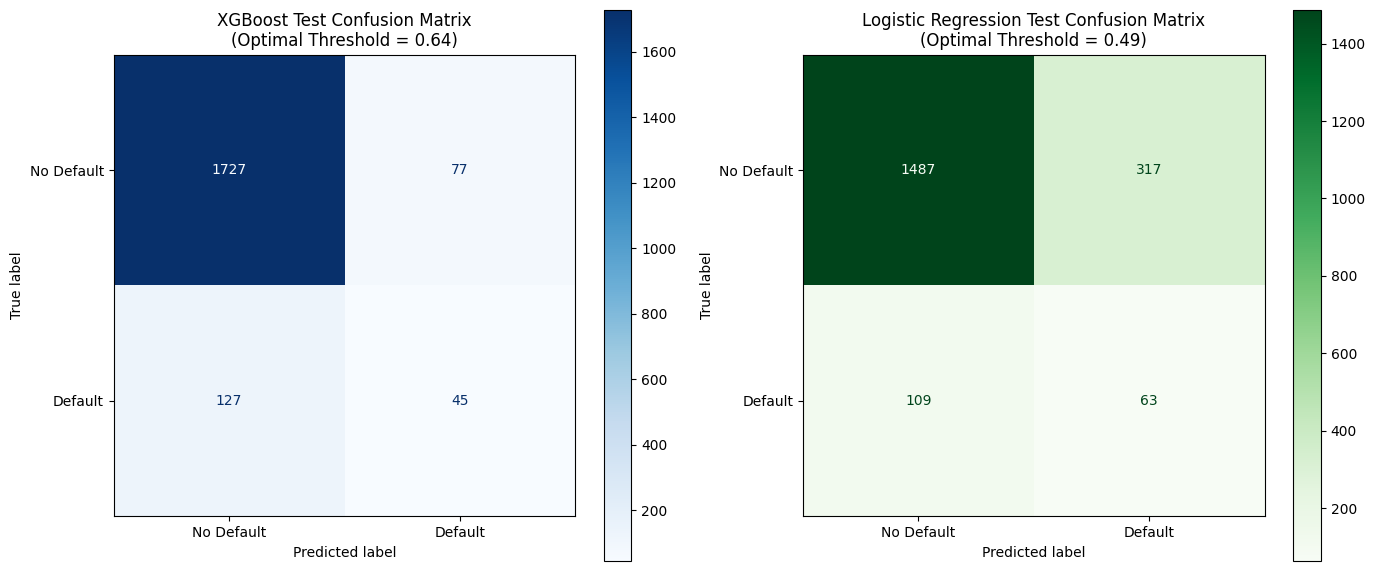

/var/folders/6r/152n25q91lzcqtjmm1gt04vc0000gn/T/ipykernel_71821/567447072.py:362: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(20), x='Importance', y='Feature', palette='viridis')


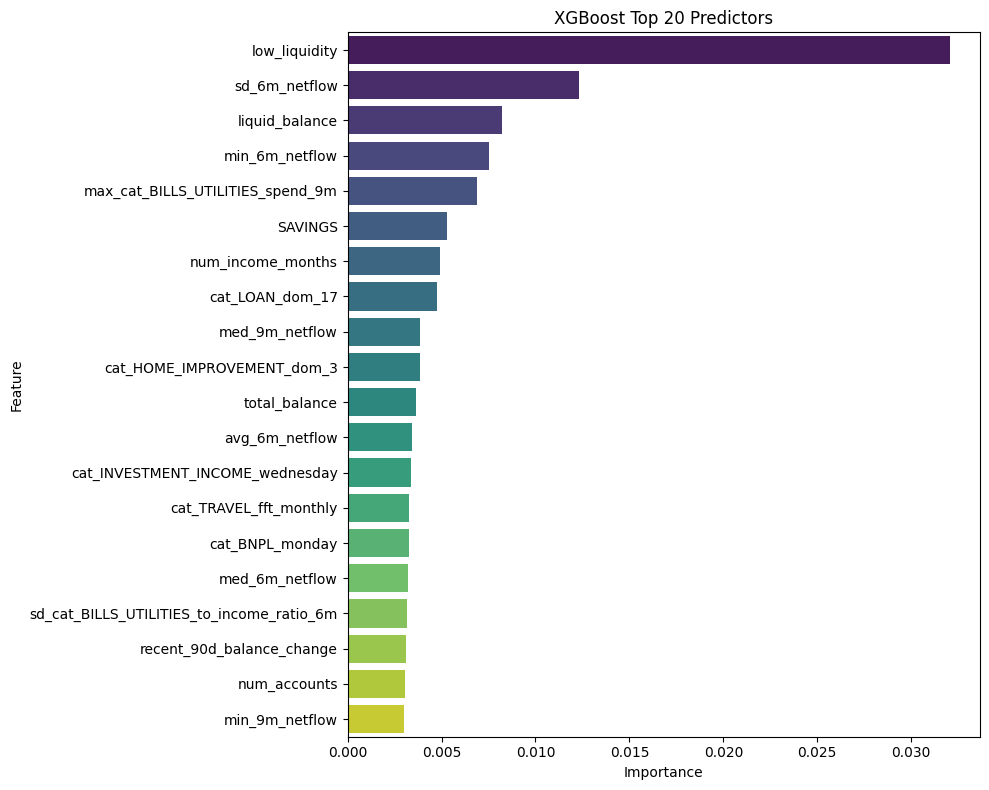

In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve
from sklearn.preprocessing import StandardScaler

def consumer_agg(df, group_col, feat_cols, window, stats=("mean", "median", "std", "min", "max"), prefix_map=None, label=None):
    if prefix_map is None:
        prefix_map = {"mean": "avg", "median": "med", "std": "sd", "min": "min", "max": "max"}
    feat_cols = list(feat_cols)
    missing = [c for c in feat_cols if c not in df.columns]
    if missing:
        raise KeyError(f"consumer_agg: missing columns in df: {missing}")
    agg_spec = {}
    single_pretty = (window is not None) and (label is not None) and (len(feat_cols) == 1)
    if single_pretty:
        c = feat_cols[0]
        for s in stats:
            agg_spec[f"{prefix_map.get(s, s)}_{int(window)}m_{label}"] = (c, s)
    else:
        for c in feat_cols:
            for s in stats:
                agg_spec[f"{prefix_map.get(s, s)}_{c}"] = (c, s)
    return df.groupby(group_col, as_index=False).agg(**agg_spec)

def build_monthly_cashflows(txn_df, window, income_cats, date_col="posted_date", amt_col="amount", consumer_col="prism_consumer_id", cd_col="credit_or_debit", cat_col="category", fill_months=True, min_periods=None, return_consumer_level=False):
    w = int(window)
    if min_periods is None:
        min_periods = w
    df = txn_df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col, consumer_col])
    df = df.sort_values([consumer_col, date_col])
    df["month"] = df[date_col].dt.to_period("M").dt.to_timestamp()
    dir_upper = df[cd_col].astype(str).str.upper()
    df[amt_col] = pd.to_numeric(df[amt_col], errors="coerce")
    df = df.dropna(subset=[amt_col])
    df["income_amt"] = np.where((dir_upper == "CREDIT") & (df[cat_col].isin(income_cats)), df[amt_col].astype(float), 0.0)
    df["spend_amt"] = np.where((dir_upper == "DEBIT"), df[amt_col].astype(float), 0.0)
    monthly = (df.groupby([consumer_col, "month"], as_index=False).agg(income=("income_amt", "sum"), spend=("spend_amt", "sum")).sort_values([consumer_col, "month"]).reset_index(drop=True))
    if fill_months and not monthly.empty:
        fill_cols = ["income", "spend"]
        def _fill(g):
            cid = g.name
            full = pd.date_range(g["month"].min(), g["month"].max(), freq="MS")
            g2 = g.set_index("month").reindex(full).rename_axis("month").reset_index()
            g2[consumer_col] = cid
            for c in fill_cols:
                if c not in g2.columns:
                    g2[c] = 0.0
            g2[fill_cols] = g2[fill_cols].fillna(0.0)
            return g2
        monthly = monthly.groupby(consumer_col, group_keys=False).apply(_fill, include_groups=False).sort_values([consumer_col, "month"]).reset_index(drop=True)
    g = monthly.groupby(consumer_col, group_keys=False)
    if w == 1:
        monthly["income_1m"] = monthly["income"]
        monthly["spend_1m"] = monthly["spend"]
        monthly["net_flow_1m"] = monthly["income_1m"] - monthly["spend_1m"]
        feat_col = "net_flow_1m"
    else:
        monthly[f"income_{w}m"] = g["income"].transform(lambda s: s.rolling(w, min_periods=min_periods).sum())
        monthly[f"spend_{w}m"]  = g["spend"].transform(lambda s: s.rolling(w, min_periods=min_periods).sum())
        monthly[f"net_flow_{w}m"] = monthly[f"income_{w}m"] - monthly[f"spend_{w}m"]
        feat_col = f"net_flow_{w}m"
    if not return_consumer_level:
        return monthly
    return consumer_agg(df=monthly, group_col=consumer_col, feat_cols=[feat_col], window=w, label="netflow")

def build_monthly_category_to_income(txn_df, income_cats, window, category_ids, date_col="posted_date", consumer_col="prism_consumer_id", amt_col="amount", direction_col="credit_or_debit", category_col="category", fill_missing_months=True, min_periods=None, consumer_level=False, agg_stats=("mean", "median", "std", "min", "max")):
    if isinstance(category_ids, (str, int, np.integer)):
        category_ids = [category_ids]
    else:
        category_ids = list(category_ids)
    category_ids = sorted(set(category_ids))
    t = txn_df[[date_col, consumer_col, amt_col, direction_col, category_col]].copy()
    t[date_col] = pd.to_datetime(t[date_col], errors="coerce")
    t = t.dropna(subset=[date_col, consumer_col])
    t[amt_col] = pd.to_numeric(t[amt_col], errors="coerce")
    t = t.dropna(subset=[amt_col])
    t["month"] = t[date_col].dt.to_period("M").dt.to_timestamp()
    dir_upper = t[direction_col].astype(str).str.upper()
    is_credit = dir_upper.eq("CREDIT")
    is_debit  = dir_upper.eq("DEBIT")
    income_cats_set = set(income_cats)
    income_m = (t.loc[is_credit & t[category_col].isin(income_cats_set)].groupby([consumer_col, "month"], as_index=False)[amt_col].sum().rename(columns={amt_col: "income_1m"}))
    spend_1m_cols = [f"cat_{cid}_spend_1m" for cid in category_ids]
    spend_m = (t.loc[is_debit & t[category_col].isin(category_ids)].groupby([consumer_col, "month", category_col])[amt_col].sum().unstack(category_col))
    if not spend_m.empty:
        spend_m = spend_m.reindex(columns=category_ids)
        spend_m.columns = spend_1m_cols
        spend_m = spend_m.reset_index()
    else:
        spend_m = pd.DataFrame(columns=[consumer_col, "month"] + spend_1m_cols)
    base = income_m.merge(spend_m, on=[consumer_col, "month"], how="outer")
    if base.empty:
        cols = [consumer_col, "month", "income_1m"] + spend_1m_cols
        return pd.DataFrame(columns=cols)
    base = base.sort_values([consumer_col, "month"]).reset_index(drop=True)
    base["income_1m"] = base["income_1m"].fillna(0.0)
    for c in spend_1m_cols:
        if c not in base.columns:
            base[c] = 0.0
    base[spend_1m_cols] = base[spend_1m_cols].fillna(0.0)
    if fill_missing_months and not base.empty:
        fill_cols = ["income_1m"] + spend_1m_cols
        spans = (base.groupby(consumer_col, as_index=False)["month"].agg(min_month="min", max_month="max"))
        spans["month"] = spans.apply(lambda r: pd.date_range(r["min_month"], r["max_month"], freq="MS"), axis=1)
        grid = spans[[consumer_col, "month"]].explode("month", ignore_index=True)
        base = grid.merge(base, on=[consumer_col, "month"], how="left")
        for c in fill_cols:
            if c not in base.columns:
                base[c] = 0.0
        base[fill_cols] = base[fill_cols].fillna(0.0)
        base = base.sort_values([consumer_col, "month"]).reset_index(drop=True)
    gb = base.groupby(consumer_col, group_keys=False)
    frames = []
    if 1 in set(int(w) for w in window):
        denom_1m = base["income_1m"].replace(0, np.nan)
        ratio_1m = base[spend_1m_cols].div(denom_1m, axis=0).rename(columns=lambda c: c.replace("_spend_1m", "_to_income_ratio_1m"))
        frames.append(ratio_1m)
    for W in [int(w) for w in window if int(w) != 1]:
        mp = W if min_periods is None else int(min_periods)
        income_roll = gb["income_1m"].transform(lambda s: s.rolling(W, min_periods=mp).sum())
        denom = income_roll.replace(0, np.nan)
        spend_roll = gb[spend_1m_cols].transform(lambda df: df.rolling(W, min_periods=mp).sum())
        spend_roll = spend_roll.rename(columns=lambda c: c.replace("_spend_1m", f"_spend_{W}m"))
        ratio = spend_roll.div(denom, axis=0).rename(columns=lambda c: c.replace("_spend_", "_to_income_ratio_"))
        frames.append(pd.concat([income_roll.rename(f"income_{W}m"), spend_roll, ratio], axis=1))
    base = pd.concat([base] + frames, axis=1).copy()
    if not consumer_level:
        return base
    agg_cols = []
    for cat_id in category_ids:
        label = f"cat_{cat_id}"
        for W in [int(w) for w in window]:
            agg_cols.extend([f"{label}_spend_{W}m" if W != 1 else f"{label}_spend_1m", f"{label}_to_income_ratio_{W}m"])
    return consumer_agg(df=base, group_col=consumer_col, feat_cols=agg_cols, window=window, stats=agg_stats)

def extract_consumer_habits(df):
    df = df.copy()
    df['posted_date'] = pd.to_datetime(df['posted_date'])
    df['day_name'] = df['posted_date'].dt.day_name().str.lower()
    df['day_of_month'] = df['posted_date'].dt.day
    day_avg = df.groupby(['prism_consumer_id', 'category', 'day_name'])['signed_amount'].mean().reset_index()
    weekly_pivot = day_avg.pivot_table(index='prism_consumer_id', columns=['category', 'day_name'], values='signed_amount').fillna(0)
    weekly_pivot.columns = [f"cat_{c}_{d}" for c, d in weekly_pivot.columns]
    dom_avg = df.groupby(['prism_consumer_id', 'category', 'day_of_month'])['signed_amount'].mean().reset_index()
    monthly_pivot = dom_avg.pivot_table(index='prism_consumer_id', columns=['category', 'day_of_month'], values='signed_amount').fillna(0)
    monthly_pivot.columns = [f"cat_{c}_dom_{d}" for c, d in monthly_pivot.columns]
    def get_dual_fft_power(series):
        if len(series) < 14 or series.sum() == 0:
            return 0, 0
        vals = series.values - series.mean()
        fft_mag = np.abs(np.fft.rfft(vals))
        fft_freq = np.fft.rfftfreq(len(vals), d=1)
        weekly_idx = np.argmin(np.abs(fft_freq - (1/7)))
        weekly_power = fft_mag[weekly_idx]
        if len(series) >= 28:
            monthly_idx = np.argmin(np.abs(fft_freq - (1/30)))
            monthly_power = fft_mag[monthly_idx]
        else:
            monthly_power = 0
        return weekly_power, monthly_power
    fft_results = []
    for (cons_id, cat), group in df.groupby(['prism_consumer_id', 'category']):
        daily_series = group.groupby('posted_date')['signed_amount'].sum()
        full_range = pd.date_range(daily_series.index.min(), daily_series.index.max())
        series = daily_series.reindex(full_range, fill_value=0)
        w_power, m_power = get_dual_fft_power(series)
        fft_results.append({'prism_consumer_id': cons_id, 'category': cat, 'fft_weekly_habit': w_power, 'fft_monthly_habit': m_power})
    fft_df = pd.DataFrame(fft_results)
    fft_pivot_w = fft_df.pivot(index='prism_consumer_id', columns='category', values='fft_weekly_habit').fillna(0)
    fft_pivot_w.columns = [f"cat_{c}_fft_weekly" for c in fft_pivot_w.columns]
    fft_pivot_m = fft_df.pivot(index='prism_consumer_id', columns='category', values='fft_monthly_habit').fillna(0)
    fft_pivot_m.columns = [f"cat_{c}_fft_monthly" for c in fft_pivot_m.columns]
    target_map = df.groupby('prism_consumer_id')['DQ_TARGET'].first()
    history_test_df = weekly_pivot.join(monthly_pivot).join(fft_pivot_w).join(fft_pivot_m).join(target_map)
    return history_test_df

def build_account_features(acctDF):
    agg_bal = acctDF.groupby("prism_consumer_id", as_index=False).agg(total_balance=("balance", "sum"), avg_balance=("balance", "mean"), max_balance=("balance", "max"), min_balance=("balance", "min"), std_balance=("balance", "std"), num_accounts=("balance", "count"))
    pivot_bal = acctDF.pivot_table(index="prism_consumer_id", columns="account_type", values="balance", aggfunc="sum", fill_value=0).reset_index()
    pivot_bal["checking_to_savings_ratio"] = pivot_bal.get("CHECKING", 0) / (pivot_bal.get("SAVINGS", 0) + 1)
    pivot_bal["has_savings_account"] = (pivot_bal.get("SAVINGS", 0) > 0).astype(int)
    keep_cols = ["prism_consumer_id", "checking_to_savings_ratio", "has_savings_account"]
    if "CHECKING" in pivot_bal: keep_cols.append("CHECKING")
    if "SAVINGS" in pivot_bal: keep_cols.append("SAVINGS")
    pivot_bal = pivot_bal[keep_cols]
    acctDF_copy = acctDF.copy()
    acctDF_copy["liquid_component"] = np.where(acctDF_copy["account_type"].isin(["CHECKING", "SAVINGS"]), acctDF_copy["balance"], 0)
    acctDF_copy["liquid_balance"] = acctDF_copy.groupby("prism_consumer_id")["liquid_component"].transform("sum")
    liquidity_flags = acctDF_copy.groupby("prism_consumer_id", as_index=False)["liquid_balance"].first()
    liquidity_flags["low_liquidity"] = (liquidity_flags["liquid_balance"] < 500).astype(int)
    liquidity_flags["is_liquid"] = (liquidity_flags["liquid_balance"] > 0).astype(int)
    return agg_bal, pivot_bal, liquidity_flags

def build_income_features(history_df):
    INCOME_CATEGORIES = ["DEPOSIT", "PAYCHECK", "PAYCHECK_PLACEHOLDER", "INVESTMENT_INCOME", "OTHER_BENEFITS", "UNEMPLOYMENT_BENEFITS", "PENSION"]
    income_txn = history_df[(history_df["credit_or_debit"] == "CREDIT") & (history_df["category"].isin(INCOME_CATEGORIES))].copy()
    income_txn["month"] = income_txn["posted_date"].dt.to_period("M")
    total_income = income_txn.groupby("prism_consumer_id", as_index=False)["amount"].sum().rename(columns={"amount": "total_income"})
    avg_monthly_income = income_txn.groupby(["prism_consumer_id", "month"])["amount"].sum().groupby("prism_consumer_id").mean().reset_index(name="avg_monthly_income")
    income_consistency = income_txn.groupby("prism_consumer_id")["month"].nunique().reset_index(name="num_income_months")
    income_sources = income_txn.groupby("prism_consumer_id")["category"].nunique().reset_index(name="num_income_sources")
    BENEFITS_CATS = ["OTHER_BENEFITS", "UNEMPLOYMENT_BENEFITS", "PENSION"]
    benefits_flag = income_txn[income_txn["category"].isin(BENEFITS_CATS)].groupby("prism_consumer_id").size().reset_index(name="benefits_txn_count")
    benefits_flag["has_benefits_income"] = (benefits_flag["benefits_txn_count"] > 0).astype(int)
    return total_income, avg_monthly_income, income_consistency, income_sources, benefits_flag[["prism_consumer_id", "has_benefits_income"]]

def build_balance_dynamics(history_df):
    df = history_df.sort_values(["prism_consumer_id", "posted_date"]).copy()
    df["daily_balance_change"] = df.groupby("prism_consumer_id")["running_balance"].diff()
    daily_change_features = df.groupby("prism_consumer_id", as_index=False).agg(mean_daily_change=("daily_balance_change", "mean"), std_daily_change=("daily_balance_change", "std"), max_daily_drop=("daily_balance_change", "min"), max_daily_increase=("daily_balance_change", "max"))
    latest_dates = df.groupby("prism_consumer_id")["posted_date"].max().reset_index(name="latest_date")
    df = df.merge(latest_dates, on="prism_consumer_id")
    df["date_30d"] = df["latest_date"] - pd.Timedelta(days=30)
    df["date_90d"] = df["latest_date"] - pd.Timedelta(days=90)
    df["date_365d"] = df["latest_date"] - pd.Timedelta(days=365)
    ending_balance = df.groupby("prism_consumer_id")["running_balance"].last()
    def last_bal(date_col):
        filtered = df[df["posted_date"] <= df[date_col]]
        return filtered.groupby("prism_consumer_id")["running_balance"].last()
    recent_balance_features = pd.DataFrame({"recent_30d_balance_change": ending_balance - last_bal("date_30d"), "recent_90d_balance_change": ending_balance - last_bal("date_90d")}).fillna(0).reset_index()
    mean_balance_features = pd.concat([df[df["posted_date"] >= df["date_30d"]].groupby("prism_consumer_id")["running_balance"].mean().rename("mean_balance_30d"), df[df["posted_date"] >= df["date_90d"]].groupby("prism_consumer_id")["running_balance"].mean().rename("mean_balance_90d"), df[df["posted_date"] >= df["date_365d"]].groupby("prism_consumer_id")["running_balance"].mean().rename("mean_balance_365d")], axis=1).reset_index()
    return daily_change_features, recent_balance_features, mean_balance_features

def build_balance_magnitude(history_df):
    df = history_df[['prism_consumer_id', 'running_balance']].copy()
    df['abs_running_balance'] = df['running_balance'].abs()
    magnitude_feats = df.groupby('prism_consumer_id')['abs_running_balance'].quantile([0.3, 0.5, 0.8]).unstack()
    magnitude_feats.columns = ['balance_magnitude_30pct', 'balance_magnitude_50pct', 'balance_magnitude_80pct']
    return magnitude_feats.reset_index()

def extract_ALL_features(history_df, acct_df, income_cats, target_cats, windows):
    base_features = extract_consumer_habits(history_df)
    if 'prism_consumer_id' in base_features.columns:
        base_features = base_features.set_index('prism_consumer_id')

    agg_bal, pivot_bal, liquidity_flags = build_account_features(acct_df)
    total_income, avg_monthly_income, income_consistency, income_sources, benefits_flag = build_income_features(history_df)
    daily_change_features, recent_balance_features, mean_balance_features = build_balance_dynamics(history_df)
    magnitude_feats = build_balance_magnitude(history_df)
    
    cashflow_dfs = []
    for w in windows:
        cf_df = build_monthly_cashflows(txn_df=history_df, window=w, income_cats=income_cats, return_consumer_level=True)
        if not cf_df.empty:
            cashflow_dfs.append(cf_df)
            
    cat_income_df = build_monthly_category_to_income(txn_df=history_df, income_cats=income_cats, window=windows, category_ids=target_cats, consumer_level=True)
    
    all_new_dfs = [
        agg_bal, pivot_bal, liquidity_flags, 
        total_income, avg_monthly_income, income_consistency, income_sources, benefits_flag, 
        daily_change_features, recent_balance_features, mean_balance_features,
        magnitude_feats
    ]
    all_new_dfs.extend(cashflow_dfs)
    if not cat_income_df.empty:
        all_new_dfs.append(cat_income_df)

    final_df = base_features.copy()
    
    for df in all_new_dfs:
        if 'prism_consumer_id' in df.columns:
            df_to_join = df.set_index('prism_consumer_id')
        elif df.index.name == 'prism_consumer_id':
            df_to_join = df
        else:
            print(f"Warning: A DataFrame is missing 'prism_consumer_id'. Columns available: {df.columns}")
            continue 
            
        final_df = final_df.join(df_to_join, how='left')

    return final_df.fillna(0).reset_index()

INCOME_CATS = ["DEPOSIT", "PAYCHECK", "INVESTMENT_INCOME", "OTHER_BENEFITS", "PENSION"] 
TARGET_SPEND_CATS = ["GROCERIES", "RENT", "BILLS_UTILITIES", "ENTERTAINMENT"] 
ROLLING_WINDOWS = [1, 3, 6, 9]

train_features_df = extract_ALL_features(history_train, train_acct, INCOME_CATS, TARGET_SPEND_CATS, ROLLING_WINDOWS)
test_features_df = extract_ALL_features(history_test, test_acct, INCOME_CATS, TARGET_SPEND_CATS, ROLLING_WINDOWS)

X_train = train_features_df.drop(columns=['DQ_TARGET', 'prism_consumer_id', 'posted_date'], errors='ignore')
y_train = train_features_df['DQ_TARGET']

X_holdout = test_features_df.drop(columns=['DQ_TARGET', 'prism_consumer_id', 'posted_date'], errors='ignore')
y_holdout = test_features_df['DQ_TARGET']

missing_cols = set(X_train.columns) - set(X_holdout.columns)
for c in missing_cols:
    X_holdout[c] = 0
X_holdout = X_holdout[X_train.columns]

# --- PREPROCESSING FOR LOGISTIC REGRESSION ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_holdout_scaled = scaler.transform(X_holdout)

ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# --- MODEL TRAINING ---
print("\n--- TRAINING XGBOOST ---")
xgb_model = xgb.XGBClassifier(n_estimators=1000, learning_rate=0.05, max_depth=3, subsample=0.8, colsample_bytree=0.5, scale_pos_weight=ratio, max_delta_step=2, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_holdout, y_holdout)], verbose=False)

print("\n--- TRAINING LOGISTIC REGRESSION ---")
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# --- PROBABILITY PREDICTIONS ---
xgb_train_probs = xgb_model.predict_proba(X_train)[:, 1]
xgb_test_probs = xgb_model.predict_proba(X_holdout)[:, 1]

lr_train_probs = lr_model.predict_proba(X_train_scaled)[:, 1]
lr_test_probs = lr_model.predict_proba(X_holdout_scaled)[:, 1]

print("\n--- MODEL PERFORMANCE (ROC AUC) ---")
print(f"XGBoost Train ROC AUC:  {roc_auc_score(y_train, xgb_train_probs):.4f}")
print(f"XGBoost Test ROC AUC:   {roc_auc_score(y_holdout, xgb_test_probs):.4f}")
print(f"LogReg Train ROC AUC:   {roc_auc_score(y_train, lr_train_probs):.4f}")
print(f"LogReg Test ROC AUC:    {roc_auc_score(y_holdout, lr_test_probs):.4f}")

# --- THRESHOLD OPTIMIZATION ---
# XGBoost Best Threshold
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_train, xgb_train_probs)
best_idx_xgb = np.argmax(tpr_xgb - fpr_xgb)
best_thresh_xgb = thresholds_xgb[best_idx_xgb]
xgb_roc_preds = (xgb_test_probs >= best_thresh_xgb).astype(int)

# Logistic Regression Best Threshold
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_train, lr_train_probs)
best_idx_lr = np.argmax(tpr_lr - fpr_lr)
best_thresh_lr = thresholds_lr[best_idx_lr]
lr_roc_preds = (lr_test_probs >= best_thresh_lr).astype(int)

# --- CONFUSION MATRICES PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot XGBoost Confusion Matrix
cm_xgb = confusion_matrix(y_holdout, xgb_roc_preds)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=["No Default", "Default"])
disp_xgb.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f"XGBoost Test Confusion Matrix\n(Optimal Threshold = {best_thresh_xgb:.2f})")

# Plot Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_holdout, lr_roc_preds)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["No Default", "Default"])
disp_lr.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title(f"Logistic Regression Test Confusion Matrix\n(Optimal Threshold = {best_thresh_lr:.2f})")

plt.tight_layout()
plt.show()

# --- XGBOOST FEATURE IMPORTANCE PLOT ---
importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': xgb_model.feature_importances_}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(20), x='Importance', y='Feature', palette='viridis')
plt.title("XGBoost Top 20 Predictors")
plt.tight_layout()
plt.show()

--- THRESHOLD OPTIMIZATION (Youden's J) ---
Optimal ROC Threshold: 0.6364

--- ADJUSTED FINAL TEST SET OUTCOMES ---
              precision    recall  f1-score   support

         0.0       0.93      0.96      0.94      1804
         1.0       0.37      0.26      0.31       172

    accuracy                           0.90      1976
   macro avg       0.65      0.61      0.63      1976
weighted avg       0.88      0.90      0.89      1976



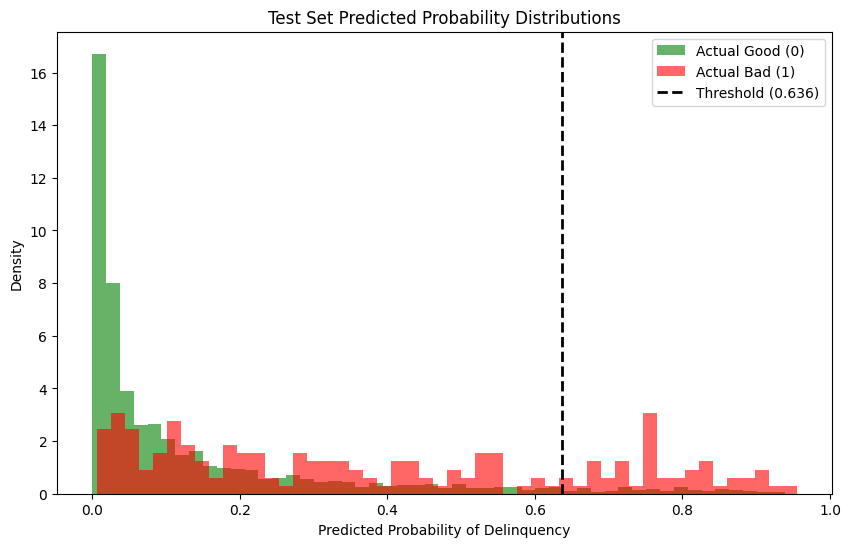

In [5]:
from sklearn.metrics import roc_curve, classification_report
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate Optimal Threshold using Youden's J statistic on the Training Set
# J = True Positive Rate (Recall) - False Positive Rate
fpr, tpr, thresholds = roc_curve(y_train, xgb_train_probs)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"--- THRESHOLD OPTIMIZATION (Youden's J) ---")
print(f"Optimal ROC Threshold: {best_threshold:.4f}\n")

# 2. Apply the new threshold to the Holdout Test Set
roc_test_preds = (xgb_test_probs >= best_threshold).astype(int)

# 3. Print the True Adjusted Outcomes
print("--- ADJUSTED FINAL TEST SET OUTCOMES ---")
print(classification_report(y_holdout, roc_test_preds))

# 4. Visualize the Probability Distributions
plt.figure(figsize=(10, 6))
# Using density=True normalizes the histograms so we can compare the shapes fairly
plt.hist(xgb_test_probs[y_holdout == 0], bins=50, alpha=0.6, label='Actual Good (0)', color='green', density=True)
plt.hist(xgb_test_probs[y_holdout == 1], bins=50, alpha=0.6, label='Actual Bad (1)', color='red', density=True)

# Draw the threshold line
plt.axvline(best_threshold, color='black', linestyle='dashed', linewidth=2, label=f'Threshold ({best_threshold:.3f})')

plt.title('Test Set Predicted Probability Distributions')
plt.xlabel('Predicted Probability of Delinquency')
plt.ylabel('Density')
plt.legend()
plt.show()

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb
from sklearn.metrics import roc_auc_score, classification_report

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

dq_consumers = history_train[history_train['DQ_TARGET'] == 1].copy()
dq_consumers['posted_date'] = pd.to_datetime(dq_consumers['posted_date'])
dq_consumers = dq_consumers.sort_values(['prism_consumer_id', 'posted_date'])

dq_consumers['days_diff'] = dq_consumers.groupby('prism_consumer_id')['posted_date'].diff().dt.days.fillna(0)
dq_consumers['category'] = dq_consumers['category'].astype('category')
category_mapping = dict(enumerate(dq_consumers['category'].cat.categories))
dq_consumers['cat_code'] = dq_consumers['category'].cat.codes

features = ['signed_amount', 'running_balance', 'days_diff', 'cat_code']
n_features = len(features)

scaler = MinMaxScaler()
dq_consumers[features] = scaler.fit_transform(dq_consumers[features].values)

seq_len = 24
stride = 12
sequences = []
zero_arr_scaled = scaler.transform(np.zeros((1, n_features)))

for user_id in dq_consumers['prism_consumer_id'].unique():
    user_data = dq_consumers[dq_consumers['prism_consumer_id'] == user_id][features].values
    if len(user_data) < seq_len:
        padding = np.repeat(zero_arr_scaled, seq_len - len(user_data), axis=0)
        sequences.append(np.vstack([padding, user_data]))
    else:
        for i in range(0, len(user_data) - seq_len + 1, stride):
            sequences.append(user_data[i : i + seq_len])

X_train_tensor = torch.FloatTensor(np.array(sequences))
train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=1024, shuffle=True)

class Embedder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, x):
        h, _ = self.rnn(x)
        return torch.sigmoid(self.fc(h))

class Recovery(nn.Module):
    def __init__(self, hidden_dim, input_dim):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, input_dim)
    def forward(self, h):
        x_tilde, _ = self.rnn(h)
        return torch.sigmoid(self.fc(x_tilde))

class Generator(nn.Module):
    def __init__(self, noise_dim, hidden_dim):
        super().__init__()
        self.rnn = nn.GRU(noise_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, z):
        h_hat, _ = self.rnn(z)
        return torch.sigmoid(self.fc(h_hat))

class Discriminator(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
    def forward(self, h):
        y_hat, _ = self.rnn(h)
        return self.fc(y_hat)

hidden_dim = 24
embedder = Embedder(n_features, hidden_dim).to(device)
recovery = Recovery(hidden_dim, n_features).to(device)
generator = Generator(hidden_dim, hidden_dim).to(device)
discriminator = Discriminator(hidden_dim).to(device)

opt_er = torch.optim.Adam(list(embedder.parameters()) + list(recovery.parameters()), lr=0.001)
opt_g = torch.optim.Adam(generator.parameters(), lr=0.001)
opt_d = torch.optim.Adam(discriminator.parameters(), lr=0.001)

epochs_embed = 20
epochs_super = 20
epochs_joint = 50

for epoch in range(epochs_embed):
    for (X_batch,) in train_loader:
        X_batch = X_batch.to(device)
        opt_er.zero_grad()
        loss_r = torch.mean((X_batch - recovery(embedder(X_batch)))**2)
        loss_r.backward()
        opt_er.step()
    if epoch % 5 == 0 or epoch == epochs_embed - 1:
        print(f"Epoch {epoch:02d}/{epochs_embed} | Reconstruction Loss: {loss_r.item():.4f}")

for epoch in range(epochs_super):
    for (X_batch,) in train_loader:
        X_batch = X_batch.to(device)
        opt_g.zero_grad()
        h_real = embedder(X_batch).detach()
        h_hat_super = generator(h_real[:, :-1, :]) 
        loss_s = torch.mean((h_hat_super - h_real[:, 1:, :])**2)
        loss_s.backward()
        opt_g.step()
    if epoch % 5 == 0 or epoch == epochs_super - 1:
        print(f"Epoch {epoch:02d}/{epochs_super} | Supervised Loss: {loss_s.item():.4f}")

for epoch in range(epochs_joint):
    for (X_batch,) in train_loader:
        X_batch = X_batch.to(device)
        curr_batch = X_batch.size(0)

        for _ in range(2):
            opt_g.zero_grad()
            Z = torch.randn(curr_batch, seq_len, hidden_dim).to(device)
            h_fake = generator(Z)
            
            loss_u = -torch.mean(torch.log(torch.sigmoid(discriminator(h_fake)) + 1e-8))
            
            h_real = embedder(X_batch).detach()
            loss_s = torch.mean((generator(h_real[:, :-1, :]) - h_real[:, 1:, :])**2)
            
            x_hat = recovery(h_fake)
            loss_v = torch.mean(torch.abs(torch.std(x_hat, dim=0) - torch.std(X_batch, dim=0)))
            
            loss_g = loss_u + 10 * torch.sqrt(loss_s) + loss_v
            loss_g.backward()
            opt_g.step()

        opt_d.zero_grad()
        Z = torch.randn(curr_batch, seq_len, hidden_dim).to(device)
        d_real = discriminator(embedder(X_batch).detach())
        d_fake = discriminator(generator(Z).detach())
        
        loss_d = -torch.mean(torch.log(torch.sigmoid(d_real) + 1e-8) + torch.log(1. - torch.sigmoid(d_fake) + 1e-8))
        if loss_d > 0.15:
            loss_d.backward()
            opt_d.step()
            
    if epoch % 10 == 0 or epoch == epochs_joint - 1:
        print(f"Epoch {epoch:02d}/{epochs_joint} | D Loss: {loss_d.item():.4f} | G Loss: {loss_g.item():.4f}")

num_new_consumers = 2000
with torch.no_grad():
    Z_new = torch.randn(num_new_consumers, seq_len, hidden_dim).to(device)
    X_new_scaled = recovery(generator(Z_new)).cpu().numpy()

X_new = scaler.inverse_transform(X_new_scaled.reshape(-1, n_features))
synthetic_df = pd.DataFrame(X_new, columns=features)

synthetic_df['cat_code'] = synthetic_df['cat_code'].round().clip(0, len(category_mapping)-1).astype(int)
synthetic_df['category'] = synthetic_df['cat_code'].map(category_mapping)

start_dates = pd.to_datetime('2021-01-01') + pd.to_timedelta(np.random.randint(0, 90, num_new_consumers), unit='D')
synthetic_ids = np.repeat(np.arange(4098016000, 4098016000 + num_new_consumers), seq_len)
synthetic_df['prism_consumer_id'] = synthetic_ids

synthetic_df['days_diff'] = synthetic_df['days_diff'].abs().round().astype(int)
synthetic_df['days_cumulative'] = synthetic_df.groupby('prism_consumer_id')['days_diff'].cumsum()
start_date_map = dict(zip(synthetic_df['prism_consumer_id'].unique(), start_dates))
synthetic_df['start_date'] = synthetic_df['prism_consumer_id'].map(start_date_map)
synthetic_df['posted_date'] = synthetic_df['start_date'] + pd.to_timedelta(synthetic_df['days_cumulative'], unit='D')

synthetic_df = synthetic_df[np.abs(synthetic_df['signed_amount']) > 1e-4]
synthetic_df['DQ_TARGET'] = 1

synthetic_trxn = synthetic_df.copy()
synthetic_trxn['amount'] = synthetic_trxn['signed_amount'].abs()
synthetic_trxn['credit_or_debit'] = np.where(synthetic_trxn['signed_amount'] < 0, 'DEBIT', 'CREDIT')

bad_ids = consDF[consDF['DQ_TARGET']==1]['prism_consumer_id'].unique()
# Force both to be strings to ensure they match
bad_ids = bad_ids.astype(str)
train_acct['prism_consumer_id'] = train_acct['prism_consumer_id'].astype(str)

real_minority_balances = train_acct[train_acct['prism_consumer_id'].isin(bad_ids)]['balance'].values
synthetic_user_ids = synthetic_trxn['prism_consumer_id'].unique()

synthetic_acct = pd.DataFrame({
    'prism_consumer_id': synthetic_user_ids,
    'balance_date': synthetic_trxn.groupby('prism_consumer_id')['posted_date'].max().values + pd.Timedelta(days=1),
    'balance': np.random.choice(real_minority_balances, size=len(synthetic_user_ids))
})

history_synthetic = calculate_running_balance(synthetic_trxn, synthetic_acct)
history_synthetic['DQ_TARGET'] = 1 

final_train_history = pd.concat([history_train, history_synthetic], axis=0, ignore_index=True)

Using device: mps
Epoch 00/20 | Reconstruction Loss: 0.0598
Epoch 05/20 | Reconstruction Loss: 0.0182
Epoch 10/20 | Reconstruction Loss: 0.0172
Epoch 15/20 | Reconstruction Loss: 0.0173
Epoch 19/20 | Reconstruction Loss: 0.0161
Epoch 00/20 | Supervised Loss: 0.0171
Epoch 05/20 | Supervised Loss: 0.0013
Epoch 10/20 | Supervised Loss: 0.0009
Epoch 15/20 | Supervised Loss: 0.0007
Epoch 19/20 | Supervised Loss: 0.0007
Epoch 00/50 | D Loss: 1.3537 | G Loss: 0.9867
Epoch 10/50 | D Loss: 1.3261 | G Loss: 1.0334
Epoch 20/50 | D Loss: 1.5428 | G Loss: 0.9059
Epoch 30/50 | D Loss: 1.3511 | G Loss: 1.0350
Epoch 40/50 | D Loss: 1.4203 | G Loss: 0.9920
Epoch 49/50 | D Loss: 1.3587 | G Loss: 1.0315



--- TRAINING XGBOOST ---

--- TRAINING LOGISTIC REGRESSION ---


/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:212: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/kylechoi/Desktop/Desktop - ky


--- MODEL PERFORMANCE (ROC AUC) ---
XGBoost Train ROC AUC:  0.9997
XGBoost Test ROC AUC:   0.7997
LogReg Train ROC AUC:   0.9955
LogReg Test ROC AUC:    0.6640


/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook

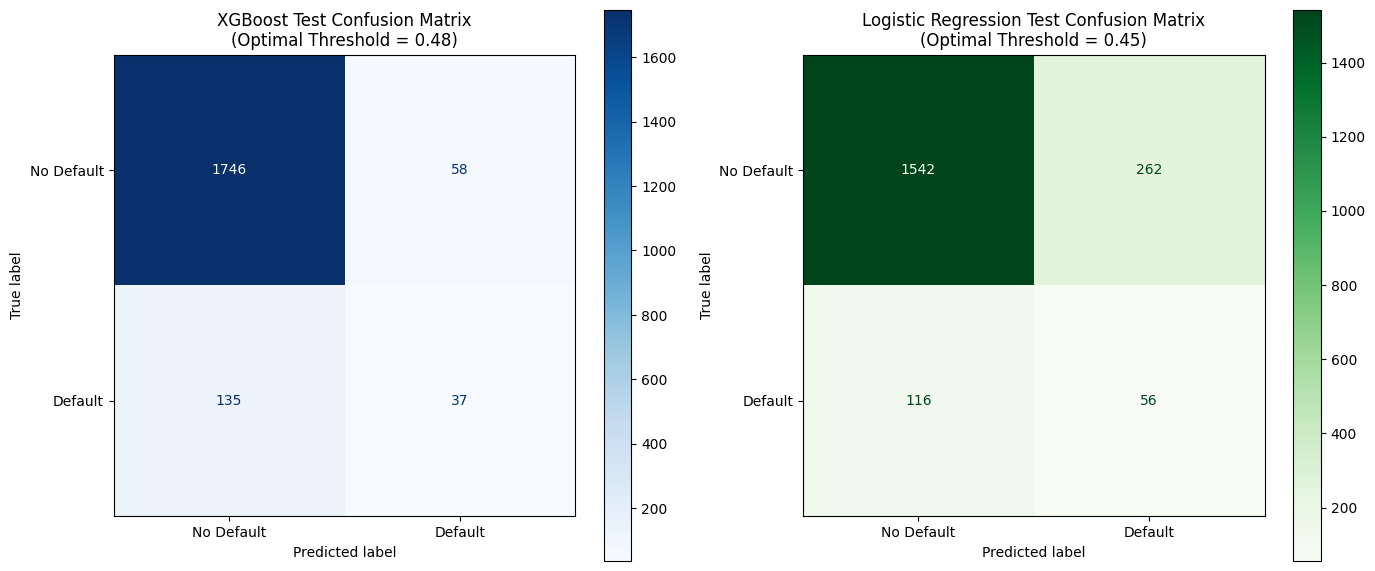

/var/folders/6r/152n25q91lzcqtjmm1gt04vc0000gn/T/ipykernel_71847/1230157560.py:362: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(20), x='Importance', y='Feature', palette='viridis')


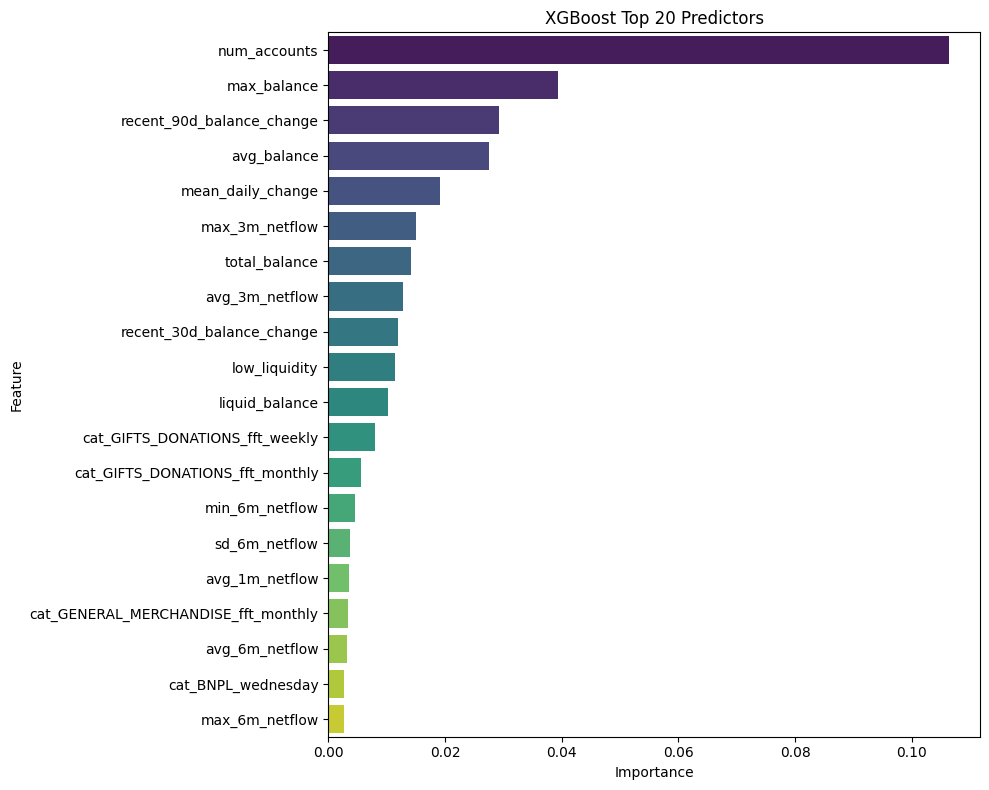

--- THRESHOLD OPTIMIZATION (Youden's J) ---
Optimal ROC Threshold: 0.4769

--- ADJUSTED FINAL TEST SET OUTCOMES ---
              precision    recall  f1-score   support

         0.0       0.93      0.97      0.95      1804
         1.0       0.39      0.22      0.28       172

    accuracy                           0.90      1976
   macro avg       0.66      0.59      0.61      1976
weighted avg       0.88      0.90      0.89      1976



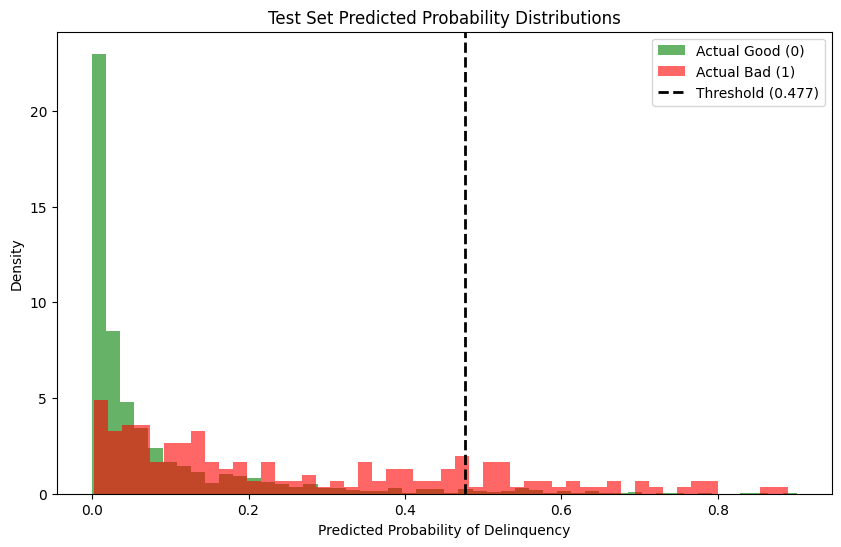

In [15]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve
from sklearn.preprocessing import StandardScaler

def consumer_agg(df, group_col, feat_cols, window, stats=("mean", "median", "std", "min", "max"), prefix_map=None, label=None):
    if prefix_map is None:
        prefix_map = {"mean": "avg", "median": "med", "std": "sd", "min": "min", "max": "max"}
    feat_cols = list(feat_cols)
    missing = [c for c in feat_cols if c not in df.columns]
    if missing:
        raise KeyError(f"consumer_agg: missing columns in df: {missing}")
    agg_spec = {}
    single_pretty = (window is not None) and (label is not None) and (len(feat_cols) == 1)
    if single_pretty:
        c = feat_cols[0]
        for s in stats:
            agg_spec[f"{prefix_map.get(s, s)}_{int(window)}m_{label}"] = (c, s)
    else:
        for c in feat_cols:
            for s in stats:
                agg_spec[f"{prefix_map.get(s, s)}_{c}"] = (c, s)
    return df.groupby(group_col, as_index=False).agg(**agg_spec)

def build_monthly_cashflows(txn_df, window, income_cats, date_col="posted_date", amt_col="amount", consumer_col="prism_consumer_id", cd_col="credit_or_debit", cat_col="category", fill_months=True, min_periods=None, return_consumer_level=False):
    w = int(window)
    if min_periods is None:
        min_periods = w
    df = txn_df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col, consumer_col])
    df = df.sort_values([consumer_col, date_col])
    df["month"] = df[date_col].dt.to_period("M").dt.to_timestamp()
    dir_upper = df[cd_col].astype(str).str.upper()
    df[amt_col] = pd.to_numeric(df[amt_col], errors="coerce")
    df = df.dropna(subset=[amt_col])
    df["income_amt"] = np.where((dir_upper == "CREDIT") & (df[cat_col].isin(income_cats)), df[amt_col].astype(float), 0.0)
    df["spend_amt"] = np.where((dir_upper == "DEBIT"), df[amt_col].astype(float), 0.0)
    monthly = (df.groupby([consumer_col, "month"], as_index=False).agg(income=("income_amt", "sum"), spend=("spend_amt", "sum")).sort_values([consumer_col, "month"]).reset_index(drop=True))
    if fill_months and not monthly.empty:
        fill_cols = ["income", "spend"]
        def _fill(g):
            cid = g.name
            full = pd.date_range(g["month"].min(), g["month"].max(), freq="MS")
            g2 = g.set_index("month").reindex(full).rename_axis("month").reset_index()
            g2[consumer_col] = cid
            for c in fill_cols:
                if c not in g2.columns:
                    g2[c] = 0.0
            g2[fill_cols] = g2[fill_cols].fillna(0.0)
            return g2
        monthly = monthly.groupby(consumer_col, group_keys=False).apply(_fill, include_groups=False).sort_values([consumer_col, "month"]).reset_index(drop=True)
    g = monthly.groupby(consumer_col, group_keys=False)
    if w == 1:
        monthly["income_1m"] = monthly["income"]
        monthly["spend_1m"] = monthly["spend"]
        monthly["net_flow_1m"] = monthly["income_1m"] - monthly["spend_1m"]
        feat_col = "net_flow_1m"
    else:
        monthly[f"income_{w}m"] = g["income"].transform(lambda s: s.rolling(w, min_periods=min_periods).sum())
        monthly[f"spend_{w}m"]  = g["spend"].transform(lambda s: s.rolling(w, min_periods=min_periods).sum())
        monthly[f"net_flow_{w}m"] = monthly[f"income_{w}m"] - monthly[f"spend_{w}m"]
        feat_col = f"net_flow_{w}m"
    if not return_consumer_level:
        return monthly
    return consumer_agg(df=monthly, group_col=consumer_col, feat_cols=[feat_col], window=w, label="netflow")

def build_monthly_category_to_income(txn_df, income_cats, window, category_ids, date_col="posted_date", consumer_col="prism_consumer_id", amt_col="amount", direction_col="credit_or_debit", category_col="category", fill_missing_months=True, min_periods=None, consumer_level=False, agg_stats=("mean", "median", "std", "min", "max")):
    if isinstance(category_ids, (str, int, np.integer)):
        category_ids = [category_ids]
    else:
        category_ids = list(category_ids)
    category_ids = sorted(set(category_ids))
    t = txn_df[[date_col, consumer_col, amt_col, direction_col, category_col]].copy()
    t[date_col] = pd.to_datetime(t[date_col], errors="coerce")
    t = t.dropna(subset=[date_col, consumer_col])
    t[amt_col] = pd.to_numeric(t[amt_col], errors="coerce")
    t = t.dropna(subset=[amt_col])
    t["month"] = t[date_col].dt.to_period("M").dt.to_timestamp()
    dir_upper = t[direction_col].astype(str).str.upper()
    is_credit = dir_upper.eq("CREDIT")
    is_debit  = dir_upper.eq("DEBIT")
    income_cats_set = set(income_cats)
    income_m = (t.loc[is_credit & t[category_col].isin(income_cats_set)].groupby([consumer_col, "month"], as_index=False)[amt_col].sum().rename(columns={amt_col: "income_1m"}))
    spend_1m_cols = [f"cat_{cid}_spend_1m" for cid in category_ids]
    spend_m = (t.loc[is_debit & t[category_col].isin(category_ids)].groupby([consumer_col, "month", category_col])[amt_col].sum().unstack(category_col))
    if not spend_m.empty:
        spend_m = spend_m.reindex(columns=category_ids)
        spend_m.columns = spend_1m_cols
        spend_m = spend_m.reset_index()
    else:
        spend_m = pd.DataFrame(columns=[consumer_col, "month"] + spend_1m_cols)
    base = income_m.merge(spend_m, on=[consumer_col, "month"], how="outer")
    if base.empty:
        cols = [consumer_col, "month", "income_1m"] + spend_1m_cols
        return pd.DataFrame(columns=cols)
    base = base.sort_values([consumer_col, "month"]).reset_index(drop=True)
    base["income_1m"] = base["income_1m"].fillna(0.0)
    for c in spend_1m_cols:
        if c not in base.columns:
            base[c] = 0.0
    base[spend_1m_cols] = base[spend_1m_cols].fillna(0.0)
    if fill_missing_months and not base.empty:
        fill_cols = ["income_1m"] + spend_1m_cols
        spans = (base.groupby(consumer_col, as_index=False)["month"].agg(min_month="min", max_month="max"))
        spans["month"] = spans.apply(lambda r: pd.date_range(r["min_month"], r["max_month"], freq="MS"), axis=1)
        grid = spans[[consumer_col, "month"]].explode("month", ignore_index=True)
        base = grid.merge(base, on=[consumer_col, "month"], how="left")
        for c in fill_cols:
            if c not in base.columns:
                base[c] = 0.0
        base[fill_cols] = base[fill_cols].fillna(0.0)
        base = base.sort_values([consumer_col, "month"]).reset_index(drop=True)
    gb = base.groupby(consumer_col, group_keys=False)
    frames = []
    if 1 in set(int(w) for w in window):
        denom_1m = base["income_1m"].replace(0, np.nan)
        ratio_1m = base[spend_1m_cols].div(denom_1m, axis=0).rename(columns=lambda c: c.replace("_spend_1m", "_to_income_ratio_1m"))
        frames.append(ratio_1m)
    for W in [int(w) for w in window if int(w) != 1]:
        mp = W if min_periods is None else int(min_periods)
        income_roll = gb["income_1m"].transform(lambda s: s.rolling(W, min_periods=mp).sum())
        denom = income_roll.replace(0, np.nan)
        spend_roll = gb[spend_1m_cols].transform(lambda df: df.rolling(W, min_periods=mp).sum())
        spend_roll = spend_roll.rename(columns=lambda c: c.replace("_spend_1m", f"_spend_{W}m"))
        ratio = spend_roll.div(denom, axis=0).rename(columns=lambda c: c.replace("_spend_", "_to_income_ratio_"))
        frames.append(pd.concat([income_roll.rename(f"income_{W}m"), spend_roll, ratio], axis=1))
    base = pd.concat([base] + frames, axis=1).copy()
    if not consumer_level:
        return base
    agg_cols = []
    for cat_id in category_ids:
        label = f"cat_{cat_id}"
        for W in [int(w) for w in window]:
            agg_cols.extend([f"{label}_spend_{W}m" if W != 1 else f"{label}_spend_1m", f"{label}_to_income_ratio_{W}m"])
    return consumer_agg(df=base, group_col=consumer_col, feat_cols=agg_cols, window=window, stats=agg_stats)

def extract_consumer_habits(df):
    df = df.copy()
    df['posted_date'] = pd.to_datetime(df['posted_date'])
    df['day_name'] = df['posted_date'].dt.day_name().str.lower()
    df['day_of_month'] = df['posted_date'].dt.day
    day_avg = df.groupby(['prism_consumer_id', 'category', 'day_name'])['signed_amount'].mean().reset_index()
    weekly_pivot = day_avg.pivot_table(index='prism_consumer_id', columns=['category', 'day_name'], values='signed_amount').fillna(0)
    weekly_pivot.columns = [f"cat_{c}_{d}" for c, d in weekly_pivot.columns]
    dom_avg = df.groupby(['prism_consumer_id', 'category', 'day_of_month'])['signed_amount'].mean().reset_index()
    monthly_pivot = dom_avg.pivot_table(index='prism_consumer_id', columns=['category', 'day_of_month'], values='signed_amount').fillna(0)
    monthly_pivot.columns = [f"cat_{c}_dom_{d}" for c, d in monthly_pivot.columns]
    def get_dual_fft_power(series):
        if len(series) < 14 or series.sum() == 0:
            return 0, 0
        vals = series.values - series.mean()
        fft_mag = np.abs(np.fft.rfft(vals))
        fft_freq = np.fft.rfftfreq(len(vals), d=1)
        weekly_idx = np.argmin(np.abs(fft_freq - (1/7)))
        weekly_power = fft_mag[weekly_idx]
        if len(series) >= 28:
            monthly_idx = np.argmin(np.abs(fft_freq - (1/30)))
            monthly_power = fft_mag[monthly_idx]
        else:
            monthly_power = 0
        return weekly_power, monthly_power
    fft_results = []
    for (cons_id, cat), group in df.groupby(['prism_consumer_id', 'category']):
        daily_series = group.groupby('posted_date')['signed_amount'].sum()
        full_range = pd.date_range(daily_series.index.min(), daily_series.index.max())
        series = daily_series.reindex(full_range, fill_value=0)
        w_power, m_power = get_dual_fft_power(series)
        fft_results.append({'prism_consumer_id': cons_id, 'category': cat, 'fft_weekly_habit': w_power, 'fft_monthly_habit': m_power})
    fft_df = pd.DataFrame(fft_results)
    fft_pivot_w = fft_df.pivot(index='prism_consumer_id', columns='category', values='fft_weekly_habit').fillna(0)
    fft_pivot_w.columns = [f"cat_{c}_fft_weekly" for c in fft_pivot_w.columns]
    fft_pivot_m = fft_df.pivot(index='prism_consumer_id', columns='category', values='fft_monthly_habit').fillna(0)
    fft_pivot_m.columns = [f"cat_{c}_fft_monthly" for c in fft_pivot_m.columns]
    target_map = df.groupby('prism_consumer_id')['DQ_TARGET'].first()
    history_test_df = weekly_pivot.join(monthly_pivot).join(fft_pivot_w).join(fft_pivot_m).join(target_map)
    return history_test_df

def build_account_features(acctDF):
    agg_bal = acctDF.groupby("prism_consumer_id", as_index=False).agg(total_balance=("balance", "sum"), avg_balance=("balance", "mean"), max_balance=("balance", "max"), min_balance=("balance", "min"), std_balance=("balance", "std"), num_accounts=("balance", "count"))
    pivot_bal = acctDF.pivot_table(index="prism_consumer_id", columns="account_type", values="balance", aggfunc="sum", fill_value=0).reset_index()
    pivot_bal["checking_to_savings_ratio"] = pivot_bal.get("CHECKING", 0) / (pivot_bal.get("SAVINGS", 0) + 1)
    pivot_bal["has_savings_account"] = (pivot_bal.get("SAVINGS", 0) > 0).astype(int)
    keep_cols = ["prism_consumer_id", "checking_to_savings_ratio", "has_savings_account"]
    if "CHECKING" in pivot_bal: keep_cols.append("CHECKING")
    if "SAVINGS" in pivot_bal: keep_cols.append("SAVINGS")
    pivot_bal = pivot_bal[keep_cols]
    acctDF_copy = acctDF.copy()
    acctDF_copy["liquid_component"] = np.where(acctDF_copy["account_type"].isin(["CHECKING", "SAVINGS"]), acctDF_copy["balance"], 0)
    acctDF_copy["liquid_balance"] = acctDF_copy.groupby("prism_consumer_id")["liquid_component"].transform("sum")
    liquidity_flags = acctDF_copy.groupby("prism_consumer_id", as_index=False)["liquid_balance"].first()
    liquidity_flags["low_liquidity"] = (liquidity_flags["liquid_balance"] < 500).astype(int)
    liquidity_flags["is_liquid"] = (liquidity_flags["liquid_balance"] > 0).astype(int)
    return agg_bal, pivot_bal, liquidity_flags

def build_income_features(history_df):
    INCOME_CATEGORIES = ["DEPOSIT", "PAYCHECK", "PAYCHECK_PLACEHOLDER", "INVESTMENT_INCOME", "OTHER_BENEFITS", "UNEMPLOYMENT_BENEFITS", "PENSION"]
    income_txn = history_df[(history_df["credit_or_debit"] == "CREDIT") & (history_df["category"].isin(INCOME_CATEGORIES))].copy()
    income_txn["month"] = income_txn["posted_date"].dt.to_period("M")
    total_income = income_txn.groupby("prism_consumer_id", as_index=False)["amount"].sum().rename(columns={"amount": "total_income"})
    avg_monthly_income = income_txn.groupby(["prism_consumer_id", "month"])["amount"].sum().groupby("prism_consumer_id").mean().reset_index(name="avg_monthly_income")
    income_consistency = income_txn.groupby("prism_consumer_id")["month"].nunique().reset_index(name="num_income_months")
    income_sources = income_txn.groupby("prism_consumer_id")["category"].nunique().reset_index(name="num_income_sources")
    BENEFITS_CATS = ["OTHER_BENEFITS", "UNEMPLOYMENT_BENEFITS", "PENSION"]
    benefits_flag = income_txn[income_txn["category"].isin(BENEFITS_CATS)].groupby("prism_consumer_id").size().reset_index(name="benefits_txn_count")
    benefits_flag["has_benefits_income"] = (benefits_flag["benefits_txn_count"] > 0).astype(int)
    return total_income, avg_monthly_income, income_consistency, income_sources, benefits_flag[["prism_consumer_id", "has_benefits_income"]]

def build_balance_dynamics(history_df):
    df = history_df.sort_values(["prism_consumer_id", "posted_date"]).copy()
    df["daily_balance_change"] = df.groupby("prism_consumer_id")["running_balance"].diff()
    daily_change_features = df.groupby("prism_consumer_id", as_index=False).agg(mean_daily_change=("daily_balance_change", "mean"), std_daily_change=("daily_balance_change", "std"), max_daily_drop=("daily_balance_change", "min"), max_daily_increase=("daily_balance_change", "max"))
    latest_dates = df.groupby("prism_consumer_id")["posted_date"].max().reset_index(name="latest_date")
    df = df.merge(latest_dates, on="prism_consumer_id")
    df["date_30d"] = df["latest_date"] - pd.Timedelta(days=30)
    df["date_90d"] = df["latest_date"] - pd.Timedelta(days=90)
    df["date_365d"] = df["latest_date"] - pd.Timedelta(days=365)
    ending_balance = df.groupby("prism_consumer_id")["running_balance"].last()
    def last_bal(date_col):
        filtered = df[df["posted_date"] <= df[date_col]]
        return filtered.groupby("prism_consumer_id")["running_balance"].last()
    recent_balance_features = pd.DataFrame({"recent_30d_balance_change": ending_balance - last_bal("date_30d"), "recent_90d_balance_change": ending_balance - last_bal("date_90d")}).fillna(0).reset_index()
    mean_balance_features = pd.concat([df[df["posted_date"] >= df["date_30d"]].groupby("prism_consumer_id")["running_balance"].mean().rename("mean_balance_30d"), df[df["posted_date"] >= df["date_90d"]].groupby("prism_consumer_id")["running_balance"].mean().rename("mean_balance_90d"), df[df["posted_date"] >= df["date_365d"]].groupby("prism_consumer_id")["running_balance"].mean().rename("mean_balance_365d")], axis=1).reset_index()
    return daily_change_features, recent_balance_features, mean_balance_features

def build_balance_magnitude(history_df):
    df = history_df[['prism_consumer_id', 'running_balance']].copy()
    df['abs_running_balance'] = df['running_balance'].abs()
    magnitude_feats = df.groupby('prism_consumer_id')['abs_running_balance'].quantile([0.3, 0.5, 0.8]).unstack()
    magnitude_feats.columns = ['balance_magnitude_30pct', 'balance_magnitude_50pct', 'balance_magnitude_80pct']
    return magnitude_feats.reset_index()

def extract_ALL_features(history_df, acct_df, income_cats, target_cats, windows):
    base_features = extract_consumer_habits(history_df)
    if 'prism_consumer_id' in base_features.columns:
        base_features = base_features.set_index('prism_consumer_id')

    agg_bal, pivot_bal, liquidity_flags = build_account_features(acct_df)
    total_income, avg_monthly_income, income_consistency, income_sources, benefits_flag = build_income_features(history_df)
    daily_change_features, recent_balance_features, mean_balance_features = build_balance_dynamics(history_df)
    magnitude_feats = build_balance_magnitude(history_df)
    
    cashflow_dfs = []
    for w in windows:
        cf_df = build_monthly_cashflows(txn_df=history_df, window=w, income_cats=income_cats, return_consumer_level=True)
        if not cf_df.empty:
            cashflow_dfs.append(cf_df)
            
    cat_income_df = build_monthly_category_to_income(txn_df=history_df, income_cats=income_cats, window=windows, category_ids=target_cats, consumer_level=True)
    
    all_new_dfs = [
        agg_bal, pivot_bal, liquidity_flags, 
        total_income, avg_monthly_income, income_consistency, income_sources, benefits_flag, 
        daily_change_features, recent_balance_features, mean_balance_features,
        magnitude_feats
    ]
    all_new_dfs.extend(cashflow_dfs)
    if not cat_income_df.empty:
        all_new_dfs.append(cat_income_df)

    final_df = base_features.copy()
    
    for df in all_new_dfs:
        if 'prism_consumer_id' in df.columns:
            df_to_join = df.set_index('prism_consumer_id')
        elif df.index.name == 'prism_consumer_id':
            df_to_join = df
        else:
            print(f"Warning: A DataFrame is missing 'prism_consumer_id'. Columns available: {df.columns}")
            continue 
            
        final_df = final_df.join(df_to_join, how='left')

    return final_df.fillna(0).reset_index()

INCOME_CATS = ["DEPOSIT", "PAYCHECK", "INVESTMENT_INCOME", "OTHER_BENEFITS", "PENSION"] 
TARGET_SPEND_CATS = ["GROCERIES", "RENT", "BILLS_UTILITIES", "ENTERTAINMENT"] 
ROLLING_WINDOWS = [1, 3, 6, 9]

train_features_df = extract_ALL_features(final_train_history, train_acct, INCOME_CATS, TARGET_SPEND_CATS, ROLLING_WINDOWS)
test_features_df = extract_ALL_features(history_test, test_acct, INCOME_CATS, TARGET_SPEND_CATS, ROLLING_WINDOWS)

X_train = train_features_df.drop(columns=['DQ_TARGET', 'prism_consumer_id', 'posted_date'], errors='ignore')
y_train = train_features_df['DQ_TARGET']

X_holdout = test_features_df.drop(columns=['DQ_TARGET', 'prism_consumer_id', 'posted_date'], errors='ignore')
y_holdout = test_features_df['DQ_TARGET']

missing_cols = set(X_train.columns) - set(X_holdout.columns)
for c in missing_cols:
    X_holdout[c] = 0
X_holdout = X_holdout[X_train.columns]

# --- PREPROCESSING FOR LOGISTIC REGRESSION ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_holdout_scaled = scaler.transform(X_holdout)

ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# --- MODEL TRAINING ---
print("\n--- TRAINING XGBOOST ---")
xgb_model = xgb.XGBClassifier(n_estimators=1000, learning_rate=0.05, max_depth=3, subsample=0.8, colsample_bytree=0.5, scale_pos_weight=ratio, max_delta_step=2, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_holdout, y_holdout)], verbose=False)

print("\n--- TRAINING LOGISTIC REGRESSION ---")
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# --- PROBABILITY PREDICTIONS ---
xgb_train_probs = xgb_model.predict_proba(X_train)[:, 1]
xgb_test_probs = xgb_model.predict_proba(X_holdout)[:, 1]

lr_train_probs = lr_model.predict_proba(X_train_scaled)[:, 1]
lr_test_probs = lr_model.predict_proba(X_holdout_scaled)[:, 1]

print("\n--- MODEL PERFORMANCE (ROC AUC) ---")
print(f"XGBoost Train ROC AUC:  {roc_auc_score(y_train, xgb_train_probs):.4f}")
print(f"XGBoost Test ROC AUC:   {roc_auc_score(y_holdout, xgb_test_probs):.4f}")
print(f"LogReg Train ROC AUC:   {roc_auc_score(y_train, lr_train_probs):.4f}")
print(f"LogReg Test ROC AUC:    {roc_auc_score(y_holdout, lr_test_probs):.4f}")

# --- THRESHOLD OPTIMIZATION ---
# XGBoost Best Threshold
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_train, xgb_train_probs)
best_idx_xgb = np.argmax(tpr_xgb - fpr_xgb)
best_thresh_xgb = thresholds_xgb[best_idx_xgb]
xgb_roc_preds = (xgb_test_probs >= best_thresh_xgb).astype(int)

# Logistic Regression Best Threshold
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_train, lr_train_probs)
best_idx_lr = np.argmax(tpr_lr - fpr_lr)
best_thresh_lr = thresholds_lr[best_idx_lr]
lr_roc_preds = (lr_test_probs >= best_thresh_lr).astype(int)

# --- CONFUSION MATRICES PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot XGBoost Confusion Matrix
cm_xgb = confusion_matrix(y_holdout, xgb_roc_preds)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=["No Default", "Default"])
disp_xgb.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f"XGBoost Test Confusion Matrix\n(Optimal Threshold = {best_thresh_xgb:.2f})")

# Plot Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_holdout, lr_roc_preds)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["No Default", "Default"])
disp_lr.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title(f"Logistic Regression Test Confusion Matrix\n(Optimal Threshold = {best_thresh_lr:.2f})")

plt.tight_layout()
plt.show()

# --- XGBOOST FEATURE IMPORTANCE PLOT ---
importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': xgb_model.feature_importances_}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(20), x='Importance', y='Feature', palette='viridis')
plt.title("XGBoost Top 20 Predictors")
plt.tight_layout()
plt.show()

from sklearn.metrics import roc_curve, classification_report
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate Optimal Threshold using Youden's J statistic on the Training Set
# J = True Positive Rate (Recall) - False Positive Rate
fpr, tpr, thresholds = roc_curve(y_train, xgb_train_probs)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"--- THRESHOLD OPTIMIZATION (Youden's J) ---")
print(f"Optimal ROC Threshold: {best_threshold:.4f}\n")

# 2. Apply the new threshold to the Holdout Test Set
roc_test_preds = (xgb_test_probs >= best_threshold).astype(int)

# 3. Print the True Adjusted Outcomes
print("--- ADJUSTED FINAL TEST SET OUTCOMES ---")
print(classification_report(y_holdout, roc_test_preds))

# 4. Visualize the Probability Distributions
plt.figure(figsize=(10, 6))
# Using density=True normalizes the histograms so we can compare the shapes fairly
plt.hist(xgb_test_probs[y_holdout == 0], bins=50, alpha=0.6, label='Actual Good (0)', color='green', density=True)
plt.hist(xgb_test_probs[y_holdout == 1], bins=50, alpha=0.6, label='Actual Bad (1)', color='red', density=True)

# Draw the threshold line
plt.axvline(best_threshold, color='black', linestyle='dashed', linewidth=2, label=f'Threshold ({best_threshold:.3f})')

plt.title('Test Set Predicted Probability Distributions')
plt.xlabel('Predicted Probability of Delinquency')
plt.ylabel('Density')
plt.legend()
plt.show()

In [14]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
import matplotlib.pyplot as plt

print("--- 1. Bootstrapping the Delinquent Data ---")

# 1. Identify Minority and Majority Users
minority_ids = history_train[history_train['DQ_TARGET'] == 1]['prism_consumer_id'].unique()
majority_ids = history_train[history_train['DQ_TARGET'] == 0]['prism_consumer_id'].unique()

n_majority = len(majority_ids)
n_minority = len(minority_ids)
n_to_sample = n_majority - n_minority

print(f"Original Good Users: {n_majority}")
print(f"Original Bad Users:  {n_minority}")
print(f"Bootstrapping {n_to_sample} additional Bad Users to balance classes...")

# 2. Sample the Minority IDs with replacement
sampled_minority_ids = np.random.choice(minority_ids, size=n_to_sample, replace=True)

# 3. Duplicate histories and assign NEW Unique IDs
bootstrapped_dfs = []
start_new_id = int(history_train['prism_consumer_id'].max()) + 1

# Extract the minority data once to speed up filtering
minority_data = history_train[history_train['prism_consumer_id'].isin(minority_ids)].set_index('prism_consumer_id')

for i, uid in enumerate(sampled_minority_ids):
    # Copy the user's exact history
    cloned_user = minority_data.loc[[uid]].copy().reset_index()
    # Assign a brand new ID so the feature extractor doesn't sum them together
    cloned_user['prism_consumer_id'] = start_new_id + i
    bootstrapped_dfs.append(cloned_user)

# Combine into one dataframe
bootstrapped_history = pd.concat(bootstrapped_dfs, ignore_index=True)
balanced_history_train = pd.concat([history_train, bootstrapped_history], ignore_index=True)


import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve
from sklearn.preprocessing import StandardScaler

def consumer_agg(df, group_col, feat_cols, window, stats=("mean", "median", "std", "min", "max"), prefix_map=None, label=None):
    if prefix_map is None:
        prefix_map = {"mean": "avg", "median": "med", "std": "sd", "min": "min", "max": "max"}
    feat_cols = list(feat_cols)
    missing = [c for c in feat_cols if c not in df.columns]
    if missing:
        raise KeyError(f"consumer_agg: missing columns in df: {missing}")
    agg_spec = {}
    single_pretty = (window is not None) and (label is not None) and (len(feat_cols) == 1)
    if single_pretty:
        c = feat_cols[0]
        for s in stats:
            agg_spec[f"{prefix_map.get(s, s)}_{int(window)}m_{label}"] = (c, s)
    else:
        for c in feat_cols:
            for s in stats:
                agg_spec[f"{prefix_map.get(s, s)}_{c}"] = (c, s)
    return df.groupby(group_col, as_index=False).agg(**agg_spec)

def build_monthly_cashflows(txn_df, window, income_cats, date_col="posted_date", amt_col="amount", consumer_col="prism_consumer_id", cd_col="credit_or_debit", cat_col="category", fill_months=True, min_periods=None, return_consumer_level=False):
    w = int(window)
    if min_periods is None:
        min_periods = w
    df = txn_df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col, consumer_col])
    df = df.sort_values([consumer_col, date_col])
    df["month"] = df[date_col].dt.to_period("M").dt.to_timestamp()
    dir_upper = df[cd_col].astype(str).str.upper()
    df[amt_col] = pd.to_numeric(df[amt_col], errors="coerce")
    df = df.dropna(subset=[amt_col])
    df["income_amt"] = np.where((dir_upper == "CREDIT") & (df[cat_col].isin(income_cats)), df[amt_col].astype(float), 0.0)
    df["spend_amt"] = np.where((dir_upper == "DEBIT"), df[amt_col].astype(float), 0.0)
    monthly = (df.groupby([consumer_col, "month"], as_index=False).agg(income=("income_amt", "sum"), spend=("spend_amt", "sum")).sort_values([consumer_col, "month"]).reset_index(drop=True))
    if fill_months and not monthly.empty:
        fill_cols = ["income", "spend"]
        def _fill(g):
            cid = g.name
            full = pd.date_range(g["month"].min(), g["month"].max(), freq="MS")
            g2 = g.set_index("month").reindex(full).rename_axis("month").reset_index()
            g2[consumer_col] = cid
            for c in fill_cols:
                if c not in g2.columns:
                    g2[c] = 0.0
            g2[fill_cols] = g2[fill_cols].fillna(0.0)
            return g2
        monthly = monthly.groupby(consumer_col, group_keys=False).apply(_fill, include_groups=False).sort_values([consumer_col, "month"]).reset_index(drop=True)
    g = monthly.groupby(consumer_col, group_keys=False)
    if w == 1:
        monthly["income_1m"] = monthly["income"]
        monthly["spend_1m"] = monthly["spend"]
        monthly["net_flow_1m"] = monthly["income_1m"] - monthly["spend_1m"]
        feat_col = "net_flow_1m"
    else:
        monthly[f"income_{w}m"] = g["income"].transform(lambda s: s.rolling(w, min_periods=min_periods).sum())
        monthly[f"spend_{w}m"]  = g["spend"].transform(lambda s: s.rolling(w, min_periods=min_periods).sum())
        monthly[f"net_flow_{w}m"] = monthly[f"income_{w}m"] - monthly[f"spend_{w}m"]
        feat_col = f"net_flow_{w}m"
    if not return_consumer_level:
        return monthly
    return consumer_agg(df=monthly, group_col=consumer_col, feat_cols=[feat_col], window=w, label="netflow")

def build_monthly_category_to_income(txn_df, income_cats, window, category_ids, date_col="posted_date", consumer_col="prism_consumer_id", amt_col="amount", direction_col="credit_or_debit", category_col="category", fill_missing_months=True, min_periods=None, consumer_level=False, agg_stats=("mean", "median", "std", "min", "max")):
    if isinstance(category_ids, (str, int, np.integer)):
        category_ids = [category_ids]
    else:
        category_ids = list(category_ids)
    category_ids = sorted(set(category_ids))
    t = txn_df[[date_col, consumer_col, amt_col, direction_col, category_col]].copy()
    t[date_col] = pd.to_datetime(t[date_col], errors="coerce")
    t = t.dropna(subset=[date_col, consumer_col])
    t[amt_col] = pd.to_numeric(t[amt_col], errors="coerce")
    t = t.dropna(subset=[amt_col])
    t["month"] = t[date_col].dt.to_period("M").dt.to_timestamp()
    dir_upper = t[direction_col].astype(str).str.upper()
    is_credit = dir_upper.eq("CREDIT")
    is_debit  = dir_upper.eq("DEBIT")
    income_cats_set = set(income_cats)
    income_m = (t.loc[is_credit & t[category_col].isin(income_cats_set)].groupby([consumer_col, "month"], as_index=False)[amt_col].sum().rename(columns={amt_col: "income_1m"}))
    spend_1m_cols = [f"cat_{cid}_spend_1m" for cid in category_ids]
    spend_m = (t.loc[is_debit & t[category_col].isin(category_ids)].groupby([consumer_col, "month", category_col])[amt_col].sum().unstack(category_col))
    if not spend_m.empty:
        spend_m = spend_m.reindex(columns=category_ids)
        spend_m.columns = spend_1m_cols
        spend_m = spend_m.reset_index()
    else:
        spend_m = pd.DataFrame(columns=[consumer_col, "month"] + spend_1m_cols)
    base = income_m.merge(spend_m, on=[consumer_col, "month"], how="outer")
    if base.empty:
        cols = [consumer_col, "month", "income_1m"] + spend_1m_cols
        return pd.DataFrame(columns=cols)
    base = base.sort_values([consumer_col, "month"]).reset_index(drop=True)
    base["income_1m"] = base["income_1m"].fillna(0.0)
    for c in spend_1m_cols:
        if c not in base.columns:
            base[c] = 0.0
    base[spend_1m_cols] = base[spend_1m_cols].fillna(0.0)
    if fill_missing_months and not base.empty:
        fill_cols = ["income_1m"] + spend_1m_cols
        spans = (base.groupby(consumer_col, as_index=False)["month"].agg(min_month="min", max_month="max"))
        spans["month"] = spans.apply(lambda r: pd.date_range(r["min_month"], r["max_month"], freq="MS"), axis=1)
        grid = spans[[consumer_col, "month"]].explode("month", ignore_index=True)
        base = grid.merge(base, on=[consumer_col, "month"], how="left")
        for c in fill_cols:
            if c not in base.columns:
                base[c] = 0.0
        base[fill_cols] = base[fill_cols].fillna(0.0)
        base = base.sort_values([consumer_col, "month"]).reset_index(drop=True)
    gb = base.groupby(consumer_col, group_keys=False)
    frames = []
    if 1 in set(int(w) for w in window):
        denom_1m = base["income_1m"].replace(0, np.nan)
        ratio_1m = base[spend_1m_cols].div(denom_1m, axis=0).rename(columns=lambda c: c.replace("_spend_1m", "_to_income_ratio_1m"))
        frames.append(ratio_1m)
    for W in [int(w) for w in window if int(w) != 1]:
        mp = W if min_periods is None else int(min_periods)
        income_roll = gb["income_1m"].transform(lambda s: s.rolling(W, min_periods=mp).sum())
        denom = income_roll.replace(0, np.nan)
        spend_roll = gb[spend_1m_cols].transform(lambda df: df.rolling(W, min_periods=mp).sum())
        spend_roll = spend_roll.rename(columns=lambda c: c.replace("_spend_1m", f"_spend_{W}m"))
        ratio = spend_roll.div(denom, axis=0).rename(columns=lambda c: c.replace("_spend_", "_to_income_ratio_"))
        frames.append(pd.concat([income_roll.rename(f"income_{W}m"), spend_roll, ratio], axis=1))
    base = pd.concat([base] + frames, axis=1).copy()
    if not consumer_level:
        return base
    agg_cols = []
    for cat_id in category_ids:
        label = f"cat_{cat_id}"
        for W in [int(w) for w in window]:
            agg_cols.extend([f"{label}_spend_{W}m" if W != 1 else f"{label}_spend_1m", f"{label}_to_income_ratio_{W}m"])
    return consumer_agg(df=base, group_col=consumer_col, feat_cols=agg_cols, window=window, stats=agg_stats)

def extract_consumer_habits(df):
    df = df.copy()
    df['posted_date'] = pd.to_datetime(df['posted_date'])
    df['day_name'] = df['posted_date'].dt.day_name().str.lower()
    df['day_of_month'] = df['posted_date'].dt.day
    day_avg = df.groupby(['prism_consumer_id', 'category', 'day_name'])['signed_amount'].mean().reset_index()
    weekly_pivot = day_avg.pivot_table(index='prism_consumer_id', columns=['category', 'day_name'], values='signed_amount').fillna(0)
    weekly_pivot.columns = [f"cat_{c}_{d}" for c, d in weekly_pivot.columns]
    dom_avg = df.groupby(['prism_consumer_id', 'category', 'day_of_month'])['signed_amount'].mean().reset_index()
    monthly_pivot = dom_avg.pivot_table(index='prism_consumer_id', columns=['category', 'day_of_month'], values='signed_amount').fillna(0)
    monthly_pivot.columns = [f"cat_{c}_dom_{d}" for c, d in monthly_pivot.columns]
    def get_dual_fft_power(series):
        if len(series) < 14 or series.sum() == 0:
            return 0, 0
        vals = series.values - series.mean()
        fft_mag = np.abs(np.fft.rfft(vals))
        fft_freq = np.fft.rfftfreq(len(vals), d=1)
        weekly_idx = np.argmin(np.abs(fft_freq - (1/7)))
        weekly_power = fft_mag[weekly_idx]
        if len(series) >= 28:
            monthly_idx = np.argmin(np.abs(fft_freq - (1/30)))
            monthly_power = fft_mag[monthly_idx]
        else:
            monthly_power = 0
        return weekly_power, monthly_power
    fft_results = []
    for (cons_id, cat), group in df.groupby(['prism_consumer_id', 'category']):
        daily_series = group.groupby('posted_date')['signed_amount'].sum()
        full_range = pd.date_range(daily_series.index.min(), daily_series.index.max())
        series = daily_series.reindex(full_range, fill_value=0)
        w_power, m_power = get_dual_fft_power(series)
        fft_results.append({'prism_consumer_id': cons_id, 'category': cat, 'fft_weekly_habit': w_power, 'fft_monthly_habit': m_power})
    fft_df = pd.DataFrame(fft_results)
    fft_pivot_w = fft_df.pivot(index='prism_consumer_id', columns='category', values='fft_weekly_habit').fillna(0)
    fft_pivot_w.columns = [f"cat_{c}_fft_weekly" for c in fft_pivot_w.columns]
    fft_pivot_m = fft_df.pivot(index='prism_consumer_id', columns='category', values='fft_monthly_habit').fillna(0)
    fft_pivot_m.columns = [f"cat_{c}_fft_monthly" for c in fft_pivot_m.columns]
    target_map = df.groupby('prism_consumer_id')['DQ_TARGET'].first()
    history_test_df = weekly_pivot.join(monthly_pivot).join(fft_pivot_w).join(fft_pivot_m).join(target_map)
    return history_test_df

def build_account_features(acctDF):
    agg_bal = acctDF.groupby("prism_consumer_id", as_index=False).agg(total_balance=("balance", "sum"), avg_balance=("balance", "mean"), max_balance=("balance", "max"), min_balance=("balance", "min"), std_balance=("balance", "std"), num_accounts=("balance", "count"))
    pivot_bal = acctDF.pivot_table(index="prism_consumer_id", columns="account_type", values="balance", aggfunc="sum", fill_value=0).reset_index()
    pivot_bal["checking_to_savings_ratio"] = pivot_bal.get("CHECKING", 0) / (pivot_bal.get("SAVINGS", 0) + 1)
    pivot_bal["has_savings_account"] = (pivot_bal.get("SAVINGS", 0) > 0).astype(int)
    keep_cols = ["prism_consumer_id", "checking_to_savings_ratio", "has_savings_account"]
    if "CHECKING" in pivot_bal: keep_cols.append("CHECKING")
    if "SAVINGS" in pivot_bal: keep_cols.append("SAVINGS")
    pivot_bal = pivot_bal[keep_cols]
    acctDF_copy = acctDF.copy()
    acctDF_copy["liquid_component"] = np.where(acctDF_copy["account_type"].isin(["CHECKING", "SAVINGS"]), acctDF_copy["balance"], 0)
    acctDF_copy["liquid_balance"] = acctDF_copy.groupby("prism_consumer_id")["liquid_component"].transform("sum")
    liquidity_flags = acctDF_copy.groupby("prism_consumer_id", as_index=False)["liquid_balance"].first()
    liquidity_flags["low_liquidity"] = (liquidity_flags["liquid_balance"] < 500).astype(int)
    liquidity_flags["is_liquid"] = (liquidity_flags["liquid_balance"] > 0).astype(int)
    return agg_bal, pivot_bal, liquidity_flags

def build_income_features(history_df):
    INCOME_CATEGORIES = ["DEPOSIT", "PAYCHECK", "PAYCHECK_PLACEHOLDER", "INVESTMENT_INCOME", "OTHER_BENEFITS", "UNEMPLOYMENT_BENEFITS", "PENSION"]
    income_txn = history_df[(history_df["credit_or_debit"] == "CREDIT") & (history_df["category"].isin(INCOME_CATEGORIES))].copy()
    income_txn["month"] = income_txn["posted_date"].dt.to_period("M")
    total_income = income_txn.groupby("prism_consumer_id", as_index=False)["amount"].sum().rename(columns={"amount": "total_income"})
    avg_monthly_income = income_txn.groupby(["prism_consumer_id", "month"])["amount"].sum().groupby("prism_consumer_id").mean().reset_index(name="avg_monthly_income")
    income_consistency = income_txn.groupby("prism_consumer_id")["month"].nunique().reset_index(name="num_income_months")
    income_sources = income_txn.groupby("prism_consumer_id")["category"].nunique().reset_index(name="num_income_sources")
    BENEFITS_CATS = ["OTHER_BENEFITS", "UNEMPLOYMENT_BENEFITS", "PENSION"]
    benefits_flag = income_txn[income_txn["category"].isin(BENEFITS_CATS)].groupby("prism_consumer_id").size().reset_index(name="benefits_txn_count")
    benefits_flag["has_benefits_income"] = (benefits_flag["benefits_txn_count"] > 0).astype(int)
    return total_income, avg_monthly_income, income_consistency, income_sources, benefits_flag[["prism_consumer_id", "has_benefits_income"]]

def build_balance_dynamics(history_df):
    df = history_df.sort_values(["prism_consumer_id", "posted_date"]).copy()
    df["daily_balance_change"] = df.groupby("prism_consumer_id")["running_balance"].diff()
    daily_change_features = df.groupby("prism_consumer_id", as_index=False).agg(mean_daily_change=("daily_balance_change", "mean"), std_daily_change=("daily_balance_change", "std"), max_daily_drop=("daily_balance_change", "min"), max_daily_increase=("daily_balance_change", "max"))
    latest_dates = df.groupby("prism_consumer_id")["posted_date"].max().reset_index(name="latest_date")
    df = df.merge(latest_dates, on="prism_consumer_id")
    df["date_30d"] = df["latest_date"] - pd.Timedelta(days=30)
    df["date_90d"] = df["latest_date"] - pd.Timedelta(days=90)
    df["date_365d"] = df["latest_date"] - pd.Timedelta(days=365)
    ending_balance = df.groupby("prism_consumer_id")["running_balance"].last()
    def last_bal(date_col):
        filtered = df[df["posted_date"] <= df[date_col]]
        return filtered.groupby("prism_consumer_id")["running_balance"].last()
    recent_balance_features = pd.DataFrame({"recent_30d_balance_change": ending_balance - last_bal("date_30d"), "recent_90d_balance_change": ending_balance - last_bal("date_90d")}).fillna(0).reset_index()
    mean_balance_features = pd.concat([df[df["posted_date"] >= df["date_30d"]].groupby("prism_consumer_id")["running_balance"].mean().rename("mean_balance_30d"), df[df["posted_date"] >= df["date_90d"]].groupby("prism_consumer_id")["running_balance"].mean().rename("mean_balance_90d"), df[df["posted_date"] >= df["date_365d"]].groupby("prism_consumer_id")["running_balance"].mean().rename("mean_balance_365d")], axis=1).reset_index()
    return daily_change_features, recent_balance_features, mean_balance_features

def build_balance_magnitude(history_df):
    df = history_df[['prism_consumer_id', 'running_balance']].copy()
    df['abs_running_balance'] = df['running_balance'].abs()
    magnitude_feats = df.groupby('prism_consumer_id')['abs_running_balance'].quantile([0.3, 0.5, 0.8]).unstack()
    magnitude_feats.columns = ['balance_magnitude_30pct', 'balance_magnitude_50pct', 'balance_magnitude_80pct']
    return magnitude_feats.reset_index()

def extract_ALL_features(history_df, acct_df, income_cats, target_cats, windows):
    base_features = extract_consumer_habits(history_df)
    if 'prism_consumer_id' in base_features.columns:
        base_features = base_features.set_index('prism_consumer_id')

    agg_bal, pivot_bal, liquidity_flags = build_account_features(acct_df)
    total_income, avg_monthly_income, income_consistency, income_sources, benefits_flag = build_income_features(history_df)
    daily_change_features, recent_balance_features, mean_balance_features = build_balance_dynamics(history_df)
    magnitude_feats = build_balance_magnitude(history_df)
    
    cashflow_dfs = []
    for w in windows:
        cf_df = build_monthly_cashflows(txn_df=history_df, window=w, income_cats=income_cats, return_consumer_level=True)
        if not cf_df.empty:
            cashflow_dfs.append(cf_df)
            
    cat_income_df = build_monthly_category_to_income(txn_df=history_df, income_cats=income_cats, window=windows, category_ids=target_cats, consumer_level=True)
    
    all_new_dfs = [
        agg_bal, pivot_bal, liquidity_flags, 
        total_income, avg_monthly_income, income_consistency, income_sources, benefits_flag, 
        daily_change_features, recent_balance_features, mean_balance_features,
        magnitude_feats
    ]
    all_new_dfs.extend(cashflow_dfs)
    if not cat_income_df.empty:
        all_new_dfs.append(cat_income_df)

    final_df = base_features.copy()
    
    for df in all_new_dfs:
        if 'prism_consumer_id' in df.columns:
            df_to_join = df.set_index('prism_consumer_id')
        elif df.index.name == 'prism_consumer_id':
            df_to_join = df
        else:
            print(f"Warning: A DataFrame is missing 'prism_consumer_id'. Columns available: {df.columns}")
            continue 
            
        final_df = final_df.join(df_to_join, how='left')

    return final_df.fillna(0).reset_index()

INCOME_CATS = ["DEPOSIT", "PAYCHECK", "INVESTMENT_INCOME", "OTHER_BENEFITS", "PENSION"] 
TARGET_SPEND_CATS = ["GROCERIES", "RENT", "BILLS_UTILITIES", "ENTERTAINMENT"] 
ROLLING_WINDOWS = [1, 3, 6, 9]

train_features_df = extract_ALL_features(balanced_history_train, train_acct, INCOME_CATS, TARGET_SPEND_CATS, ROLLING_WINDOWS)
test_features_df = extract_ALL_features(history_test, test_acct, INCOME_CATS, TARGET_SPEND_CATS, ROLLING_WINDOWS)

X_train = train_features_df.drop(columns=['DQ_TARGET', 'prism_consumer_id', 'posted_date'], errors='ignore')
y_train = train_features_df['DQ_TARGET']

X_holdout = test_features_df.drop(columns=['DQ_TARGET', 'prism_consumer_id', 'posted_date'], errors='ignore')
y_holdout = test_features_df['DQ_TARGET']

missing_cols = set(X_train.columns) - set(X_holdout.columns)
for c in missing_cols:
    X_holdout[c] = 0
X_holdout = X_holdout[X_train.columns]

# --- PREPROCESSING FOR LOGISTIC REGRESSION ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_holdout_scaled = scaler.transform(X_holdout)

ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# --- MODEL TRAINING ---
print("\n--- TRAINING XGBOOST ---")
xgb_model = xgb.XGBClassifier(n_estimators=1000, learning_rate=0.05, max_depth=3, subsample=0.8, colsample_bytree=0.5, scale_pos_weight=ratio, max_delta_step=2, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_holdout, y_holdout)], verbose=False)

print("\n--- TRAINING LOGISTIC REGRESSION ---")
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# --- PROBABILITY PREDICTIONS ---
xgb_train_probs = xgb_model.predict_proba(X_train)[:, 1]
xgb_test_probs = xgb_model.predict_proba(X_holdout)[:, 1]

lr_train_probs = lr_model.predict_proba(X_train_scaled)[:, 1]
lr_test_probs = lr_model.predict_proba(X_holdout_scaled)[:, 1]

print("\n--- MODEL PERFORMANCE (ROC AUC) ---")
print(f"XGBoost Train ROC AUC:  {roc_auc_score(y_train, xgb_train_probs):.4f}")
print(f"XGBoost Test ROC AUC:   {roc_auc_score(y_holdout, xgb_test_probs):.4f}")
print(f"LogReg Train ROC AUC:   {roc_auc_score(y_train, lr_train_probs):.4f}")
print(f"LogReg Test ROC AUC:    {roc_auc_score(y_holdout, lr_test_probs):.4f}")

# --- THRESHOLD OPTIMIZATION ---
# XGBoost Best Threshold
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_train, xgb_train_probs)
best_idx_xgb = np.argmax(tpr_xgb - fpr_xgb)
best_thresh_xgb = thresholds_xgb[best_idx_xgb]
xgb_roc_preds = (xgb_test_probs >= best_thresh_xgb).astype(int)

# Logistic Regression Best Threshold
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_train, lr_train_probs)
best_idx_lr = np.argmax(tpr_lr - fpr_lr)
best_thresh_lr = thresholds_lr[best_idx_lr]
lr_roc_preds = (lr_test_probs >= best_thresh_lr).astype(int)

# --- CONFUSION MATRICES PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot XGBoost Confusion Matrix
cm_xgb = confusion_matrix(y_holdout, xgb_roc_preds)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=["No Default", "Default"])
disp_xgb.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f"XGBoost Test Confusion Matrix\n(Optimal Threshold = {best_thresh_xgb:.2f})")

# Plot Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_holdout, lr_roc_preds)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["No Default", "Default"])
disp_lr.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title(f"Logistic Regression Test Confusion Matrix\n(Optimal Threshold = {best_thresh_lr:.2f})")

plt.tight_layout()
plt.show()

# --- XGBOOST FEATURE IMPORTANCE PLOT ---
importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': xgb_model.feature_importances_}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(20), x='Importance', y='Feature', palette='viridis')
plt.title("XGBoost Top 20 Predictors")
plt.tight_layout()
plt.show()



--- 1. Bootstrapping the Delinquent Data ---
Original Good Users: 7218
Original Bad Users:  686
Bootstrapping 6532 additional Bad Users to balance classes...

--- TRAINING XGBOOST ---


KeyboardInterrupt: 


--- CALCULATING FEATURE SPARSITY ---
                                 Feature  Active_Users Pct_Active Verdict
                       num_income_months         13882      96.2%    KEEP
                            num_accounts          7904      54.8%    KEEP
                           total_balance          7829      54.2%    KEEP
                             avg_balance          7829      54.2%    KEEP
                          liquid_balance          7829      54.2%    KEEP
                             max_balance          7814      54.1%    KEEP
                                CHECKING          7727      53.5%    KEEP
                               is_liquid          7620      52.8%    KEEP
                          avg_6m_netflow          5876      40.7%    KEEP
                          min_6m_netflow          5872      40.7%    KEEP
                          max_6m_netflow          5872      40.7%    KEEP
                           sd_6m_netflow          5306      36.8%    KEEP


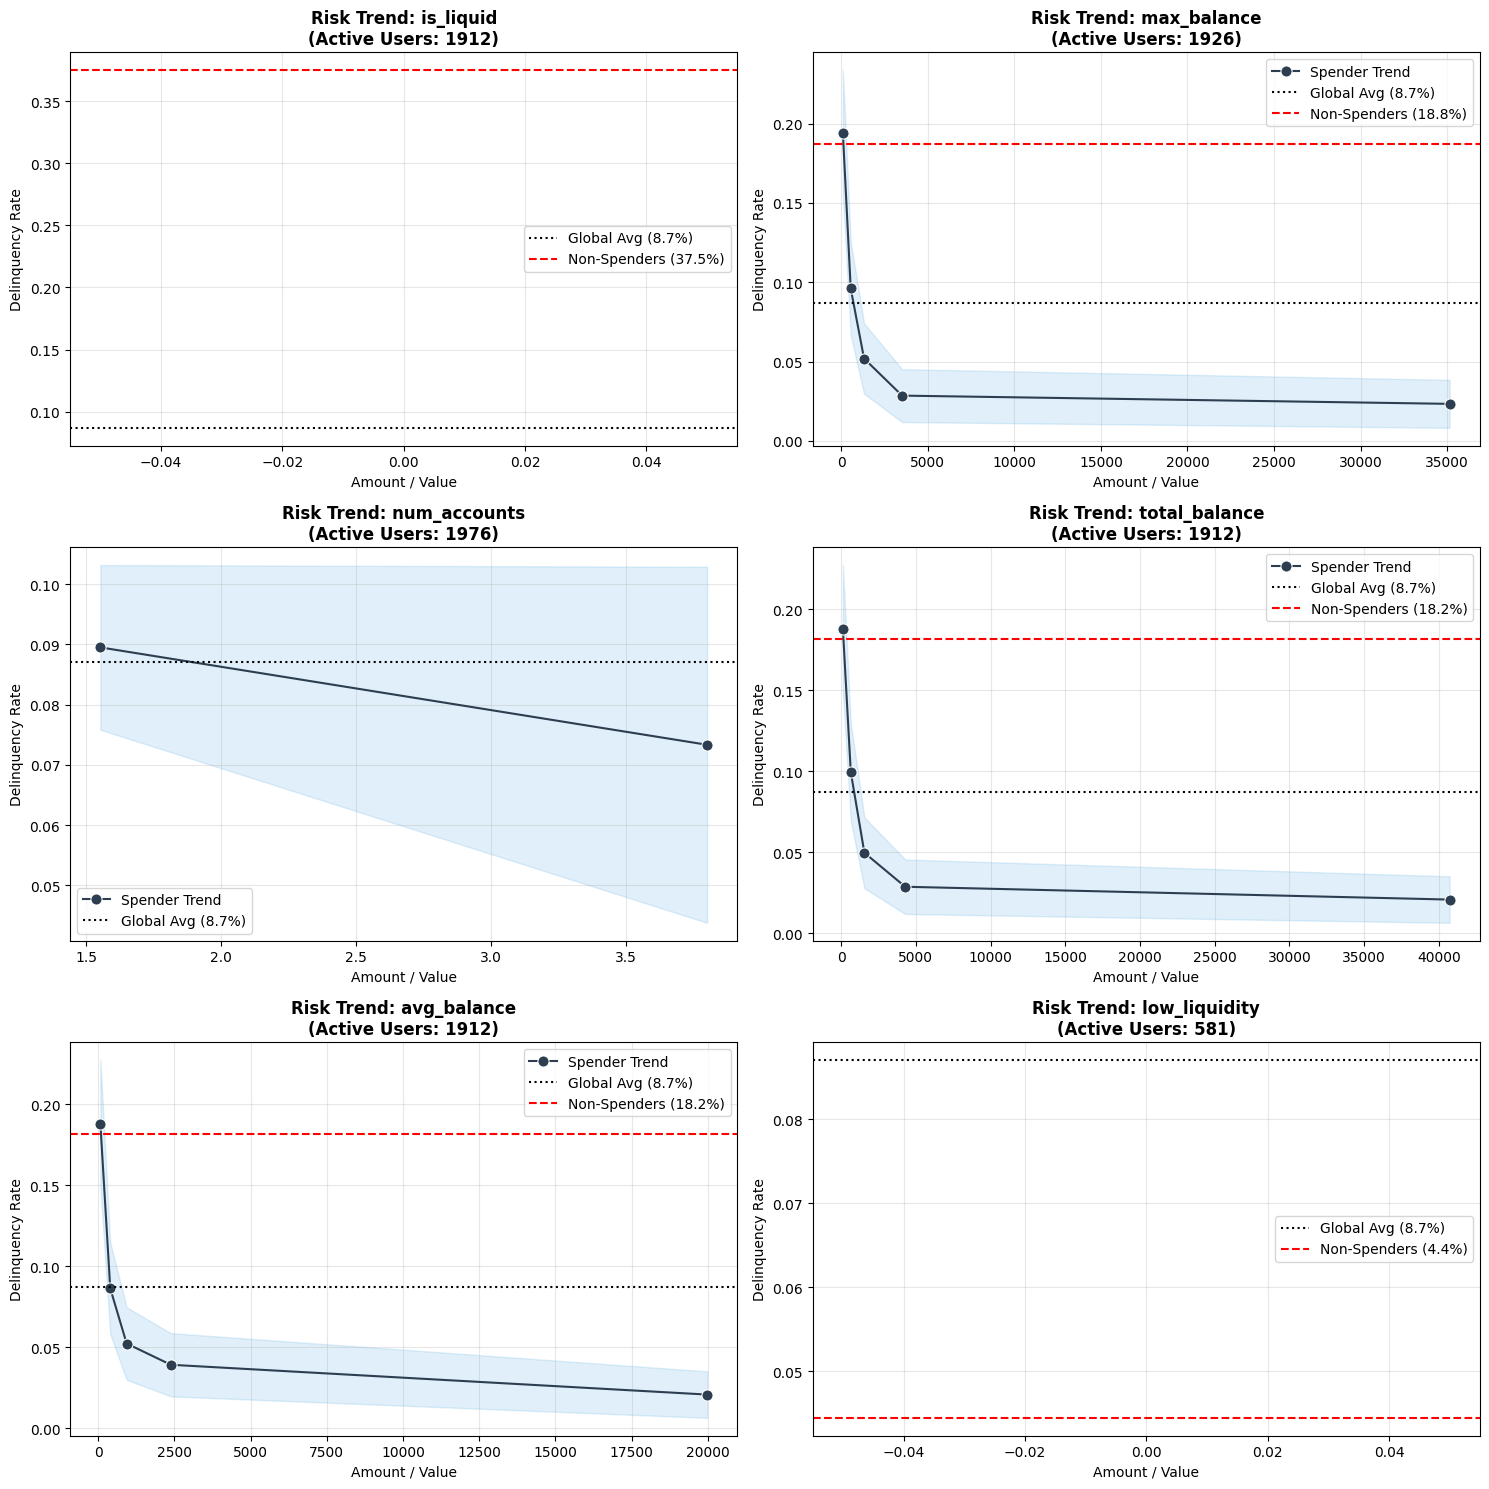

In [12]:
# ==========================================
# 6. SPARSITY & RISK TREND ANALYSIS
# ==========================================
print("\n--- CALCULATING FEATURE SPARSITY ---")

features_to_check = importance_df.head(20)['Feature'].to_list()

sparsity_check = []
for col in features_to_check:
    non_zeros = (train_features_df[col] != 0).sum()
    total = len(train_features_df)
    pct_active = non_zeros / total
    
    sparsity_check.append({
        'Feature': col,
        'Active_Users': non_zeros,
        'Pct_Active': f"{pct_active:.1%}",
        'Verdict': 'KEEP' if non_zeros > 100 else 'DROP / FLAG'
    })

sparsity_df = pd.DataFrame(sparsity_check).sort_values('Active_Users', ascending=False)
print(sparsity_df.to_string(index=False))

def plot_risk_trends_nonzero(df, features, target='DQ_TARGET', q=5):
    n_features = len(features)
    n_cols = 2
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for i, col in enumerate(features):
        ax = axes[i]
        zeros = df[df[col] == 0]
        non_zeros = df[df[col] > 0].copy()
        
        global_risk = df[target].mean()
        
        # Safely calculate zero_risk in case the feature is 100% populated
        if len(zeros) > 0:
            zero_risk = zeros[target].mean()
        else:
            zero_risk = global_risk 
        
        if len(non_zeros) > 50:
            try:
                non_zeros['bin'] = pd.qcut(non_zeros[col], q=q, duplicates='drop')
            except ValueError:
                 non_zeros['bin'] = pd.qcut(non_zeros[col].rank(method='first'), q=q)
                 
            agg_data = non_zeros.groupby('bin', observed=True).agg({
                col: 'mean',
                target: ['mean', 'sem', 'count']
            })
            agg_data.columns = ['avg_spend', 'risk_rate', 'std_err', 'count']
            agg_data = agg_data.reset_index()

            sns.lineplot(
                ax=ax, x=agg_data['avg_spend'], y=agg_data['risk_rate'],
                marker='o', markersize=8, color='#2c3e50', label='Spender Trend'
            )
            
            lower = agg_data['risk_rate'] - 1.96 * agg_data['std_err']
            upper = agg_data['risk_rate'] + 1.96 * agg_data['std_err']
            ax.fill_between(agg_data['avg_spend'], lower, upper, color='#3498db', alpha=0.15)
        else:
            ax.text(0.5, 0.5, "Not enough spenders to plot trend", ha='center', va='center')

        ax.axhline(global_risk, color='black', linestyle=':', label=f'Global Avg ({global_risk:.1%})')
        if len(zeros) > 0:
            ax.axhline(zero_risk, color='red', linestyle='--', label=f'Non-Spenders ({zero_risk:.1%})')
        
        ax.set_title(f'Risk Trend: {col}\n(Active Users: {len(non_zeros)})', fontweight='bold')
        ax.set_ylabel('Delinquency Rate')
        ax.set_xlabel('Amount / Value')
        ax.legend()
        ax.grid(True, alpha=0.3)

    # Hide any unused subplots (e.g., if checking 19 features instead of 20)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

print("\n--- PLOTTING RISK TRENDS FOR TOP FEATURES ---")
# Slice the list to get the first 6 items
top_6_features = features_to_check[:6] 

plot_risk_trends_nonzero(test_features_df, top_6_features)

--- THRESHOLD OPTIMIZATION (Youden's J) ---
Optimal ROC Threshold: 0.3521

--- ADJUSTED FINAL TEST SET OUTCOMES ---
              precision    recall  f1-score   support

         0.0       0.92      0.97      0.95      1804
         1.0       0.36      0.17      0.23       172

    accuracy                           0.90      1976
   macro avg       0.64      0.57      0.59      1976
weighted avg       0.88      0.90      0.88      1976



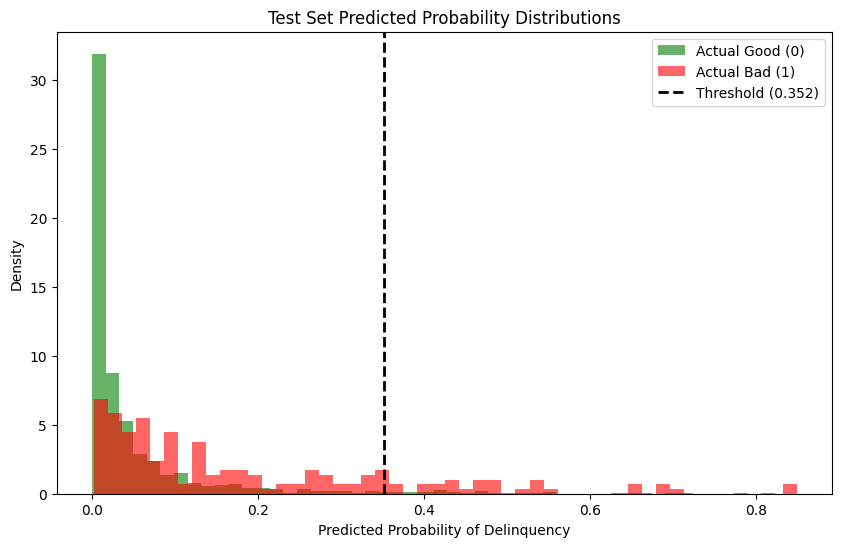

In [13]:
from sklearn.metrics import roc_curve, classification_report
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate Optimal Threshold using Youden's J statistic on the Training Set
# J = True Positive Rate (Recall) - False Positive Rate
fpr, tpr, thresholds = roc_curve(y_train, xgb_train_probs)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"--- THRESHOLD OPTIMIZATION (Youden's J) ---")
print(f"Optimal ROC Threshold: {best_threshold:.4f}\n")

# 2. Apply the new threshold to the Holdout Test Set
roc_test_preds = (xgb_test_probs >= best_threshold).astype(int)

# 3. Print the True Adjusted Outcomes
print("--- ADJUSTED FINAL TEST SET OUTCOMES ---")
print(classification_report(y_holdout, roc_test_preds))

# 4. Visualize the Probability Distributions
plt.figure(figsize=(10, 6))
# Using density=True normalizes the histograms so we can compare the shapes fairly
plt.hist(xgb_test_probs[y_holdout == 0], bins=50, alpha=0.6, label='Actual Good (0)', color='green', density=True)
plt.hist(xgb_test_probs[y_holdout == 1], bins=50, alpha=0.6, label='Actual Bad (1)', color='red', density=True)

# Draw the threshold line
plt.axvline(best_threshold, color='black', linestyle='dashed', linewidth=2, label=f'Threshold ({best_threshold:.3f})')

plt.title('Test Set Predicted Probability Distributions')
plt.xlabel('Predicted Probability of Delinquency')
plt.ylabel('Density')
plt.legend()
plt.show()